In [114]:
# Importation des librairies de base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import argparse

# Données
import wrds

#2.1
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from sklearn.metrics import mean_squared_error

#2.2
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox

#2.3 
import statsmodels.api as sm
from statsmodels.tsa.api import AutoReg

# 2.4
from dataclasses import dataclass
from scipy import stats

In [2]:
db = wrds.Connection(wrds_username='lilas_bertot')

Loading library list...
Done
Done


In [5]:
# Enlever tous les messages de prévention sous les résultats 
import warnings
warnings.filterwarnings('ignore')

# PRÉPARATION DES DONNÉES

In [ ]:
# Extraction données S&P 500 dans wrds
spx_query = """
SELECT date, spindx as prc
FROM crsp.dsi
WHERE date >= '2010-01-01'
AND spindx IS NOT NULL
ORDER BY date;
"""
spx_data = db.raw_sql(spx_query, date_cols=['date'])
spx_data = spx_data.rename(columns={'prc': 'SP500'})
spx_data['date'] = pd.to_datetime(spx_data['date'])

print(spx_data)
print("Nombre d’observations :", len(spx_data))

           date    SP500
0    2010-01-04  1132.99
1    2010-01-05  1136.52
2    2010-01-06  1137.14
3    2010-01-07  1141.69
4    2010-01-08  1144.98
...         ...      ...
3769 2024-12-24  6040.04
3770 2024-12-26  6037.59
3771 2024-12-27  5970.84
3772 2024-12-30  5906.94
3773 2024-12-31  5881.63

[3774 rows x 2 columns]
Nombre d’observations : 3774


In [8]:
# Extraction données indices boursier 3 marchés développés: DAX (Allemagne), Nikkei225 (Japon), FTSE100 (Royaume-Uni)
# Extraction données indices boursier 2 marchés émergents: Bovespa (Brésil), Nifty50 (Inde)

intern_indices_query = """
SELECT 
    datadate,
    MAX(CASE WHEN gvkeyx = '150095' THEN prccd END) AS DAX,
    MAX(CASE WHEN gvkeyx = '150008' THEN prccd END) AS FTSE100,
    MAX(CASE WHEN gvkeyx = '150069' THEN prccd END) AS Nikkei225,
    MAX(CASE WHEN gvkeyx = '150086' THEN prccd END) AS Bovespa,
    MAX(CASE WHEN gvkeyx = '151120' THEN prccd END) AS Nifty50
FROM comp.g_idx_daily
WHERE gvkeyx IN ('150095', '150008', '150069', '150086', '151120')
  AND datadate >= '2010-01-01'
  AND prccd IS NOT NULL
GROUP BY datadate
ORDER BY datadate
"""
intern_indices_data = db.raw_sql(intern_indices_query, date_cols=['datadate'])
intern_indices_data['datadate'] = pd.to_datetime(intern_indices_data['datadate'])

intern_indices_data.columns = ['datadate', 'DAX', 'FTSE100', 'Nikkei225', 'Bovespa', 'Nifty50']

print(intern_indices_data)
print("Nombre d’observations :", len(intern_indices_data))

       datadate       DAX    FTSE100  Nikkei225    Bovespa  Nifty50
0    2010-01-01   5957.43    5412.88   10546.44   68588.41  5201.05
1    2010-01-04    6048.3    5500.34   10654.79   70045.08   5232.2
2    2010-01-05   6031.86     5522.5   10681.83   70239.82   5277.9
3    2010-01-06   6034.33    5530.04   10731.45   70729.34   5281.8
4    2010-01-07   6019.36    5526.72   10681.66   70451.12   5263.1
...         ...       ...        ...        ...        ...      ...
4147 2025-11-07  23569.96  9682.5741   50276.37  154063.53  25492.3
4148 2025-11-10  23959.99  9787.1465   50911.76  155257.31  25574.3
4149 2025-11-11  24088.06  9899.5997   50842.93   157748.6  25695.0
4150 2025-11-12  24381.46   9911.419   51063.31   157632.9  25875.8
4151 2025-11-13  24041.62  9807.6777   51281.83  157162.43  25879.2

[4152 rows x 6 columns]
Nombre d’observations : 4152


In [11]:
# Fusion données tous indices
data_dict = {
    'DAX': intern_indices_data[['DAX']],
    'FTSE100': intern_indices_data[['FTSE100']],
    'NIKKEI225': intern_indices_data[['Nikkei225']],
    'BOVESPA': intern_indices_data[['Bovespa']],
    'NIFTY50': intern_indices_data[['Nifty50']]
}

# SP500 comme base
spx_df = spx_data.set_index('date')[['SP500']]

# Fusionner sur toutes les dates communes (indices ont différents fériés, etc.)
all_data = spx_df.copy()
for name, df in data_dict.items():
    df = df.set_index(intern_indices_data['datadate']) 
    all_data = all_data.join(df, how='inner')

common_dates = all_data.dropna().index
all_data = all_data.loc[common_dates]

print("Données fusionnées :")
print(all_data)

print("Nombre d’observations par indice après la fusion des données :")
print(all_data.count())

print("Période couverte par tous les indices :")
print(all_data.index.min().date(), "à", all_data.index.max().date())

Données fusionnées :
              SP500       DAX    FTSE100  Nikkei225    Bovespa  Nifty50
2010-01-04  1132.99    6048.3    5500.34   10654.79   70045.08   5232.2
2010-01-05  1136.52   6031.86     5522.5   10681.83   70239.82   5277.9
2010-01-06  1137.14   6034.33    5530.04   10731.45   70729.34   5281.8
2010-01-07  1141.69   6019.36    5526.72   10681.66   70451.12   5263.1
2010-01-08  1144.98   6037.61    5534.24   10798.32    70262.7  5244.75
...             ...       ...        ...        ...        ...      ...
2024-12-24  6040.04  19848.77  8136.9933   39036.85  120766.57  23727.7
2024-12-26  6037.59  19848.77  8136.9933   39568.06   121077.5  23750.2
2024-12-27  5970.84  19984.32  8149.7804   40281.16  120269.31  23813.4
2024-12-30  5906.94  19909.14  8121.0077   39894.54   120283.4  23644.9
2024-12-31  5881.63  19909.14  8173.0239   39894.54   120283.4  23644.8

[3773 rows x 6 columns]
Nombre d’observations par indice après la fusion des données :
SP500        3773
DAX      

# PARTIE 2.1

In [12]:
# Calcul rendements journaliers 
returns = np.log(all_data / all_data.shift(1))
returns = returns.dropna(how="any")

print("Aperçu rendements :")
print(returns)

Aperçu rendements :
               SP500       DAX   FTSE100  Nikkei225   Bovespa   Nifty50
2010-01-05  0.003111 -0.002722  0.004021   0.002535  0.002776  0.008696
2010-01-06  0.000545  0.000409  0.001364   0.004635  0.006945  0.000739
2010-01-07  0.003993 -0.002484 -0.000601   -0.00465 -0.003941 -0.003547
2010-01-08  0.002878  0.003027   0.00136   0.010862 -0.002678 -0.003493
2010-01-11  0.001745  0.000479  0.000692        0.0  0.002428  0.000886
...              ...       ...       ...        ...       ...       ...
2024-12-24  0.010982       0.0  0.004221  -0.003184       0.0 -0.001085
2024-12-26 -0.000406       0.0       0.0   0.013516  0.002571  0.000948
2024-12-27 -0.011117  0.006806   0.00157   0.017862 -0.006697  0.002657
2024-12-30  -0.01076 -0.003769 -0.003537  -0.009644  0.000117 -0.007101
2024-12-31 -0.004294       0.0  0.006385        0.0       0.0 -0.000004

[3772 rows x 6 columns]


<Figure size 1200x600 with 0 Axes>

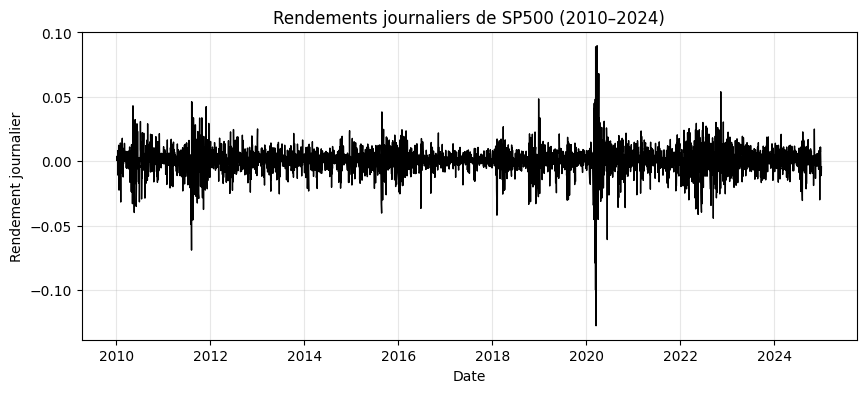

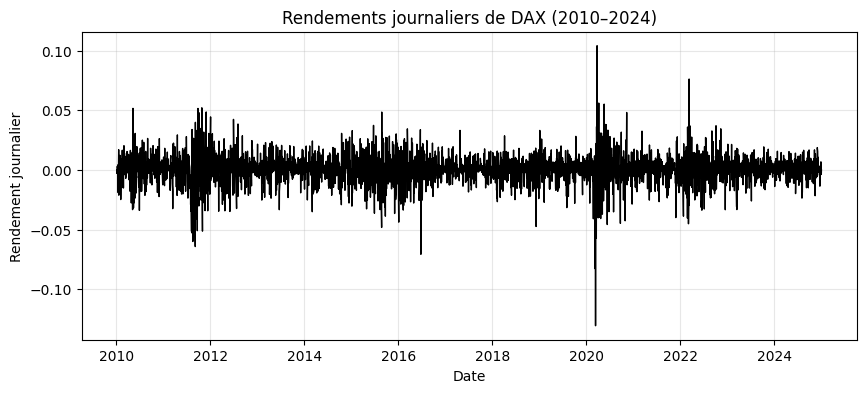

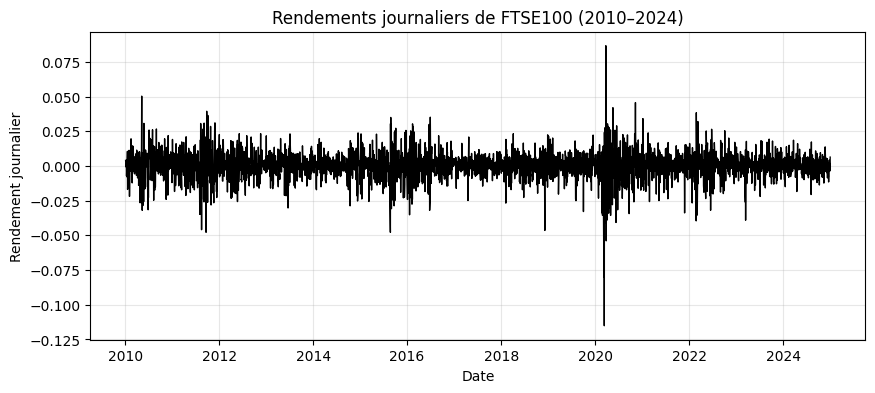

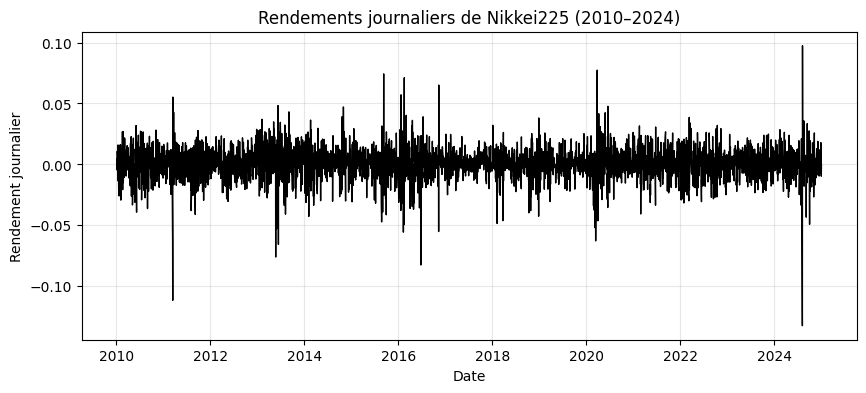

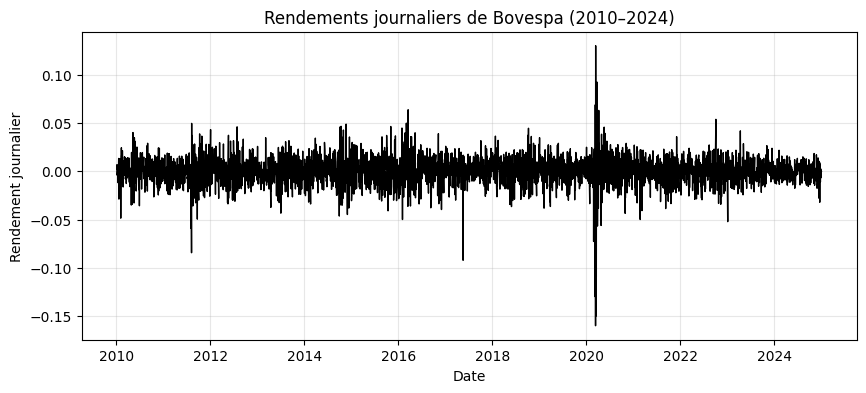

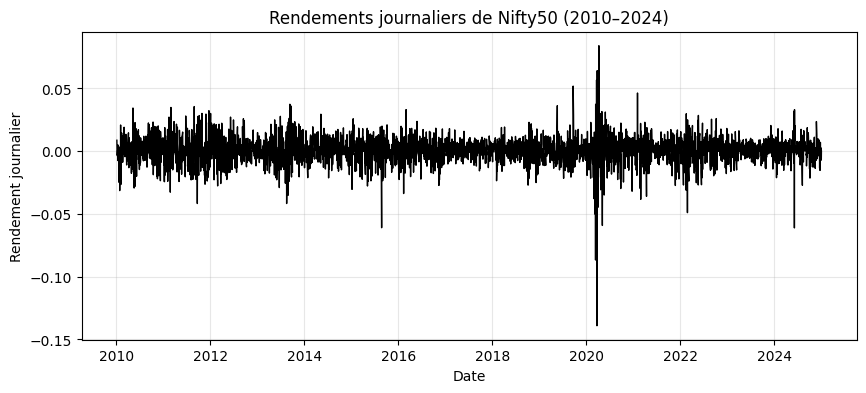

In [14]:
# Graphique des rendements journaliers
plt.figure(figsize=(12,6))
for col in returns.columns:
    plt.figure(figsize=(10, 4))
    plt.plot(returns.index, returns[col], color='black', linewidth=1)
    plt.title(f"Rendements journaliers de {col} (2010–2024)")
    plt.xlabel("Date")
    plt.ylabel("Rendement journalier")
    plt.grid(True, alpha=0.3)
    plt.show()

In [15]:
# fenêtre 126 jours comme demandé
WIN = 126 

# Corrélation mobile entre SP500 et chaque autre indice
corr_cols = ['DAX','Nikkei225','FTSE100','Bovespa','Nifty50']
corr_mob = pd.DataFrame(index=returns.index)

for col in corr_cols:
    corr_mob[f'corr_SP500_{col}'] = returns['SP500'].rolling(WIN).corr(returns[col])

corr_mob = corr_mob.dropna()

print("Corrélations mobiles (126j) :")
print(corr_mob)
print("\nNombre d'observations par série de corrélation :")
print(corr_mob.count())

Corrélations mobiles (126j) :
            corr_SP500_DAX  corr_SP500_Nikkei225  corr_SP500_FTSE100  \
2010-07-06        0.635893              0.210762            0.652437   
2010-07-07        0.633235              0.197942            0.651739   
2010-07-08        0.634284              0.206302            0.653415   
2010-07-09        0.635668              0.208772            0.654471   
2010-07-12        0.635538              0.207499            0.653911   
...                    ...                   ...                 ...   
2024-12-24        0.447845              0.369157            0.364970   
2024-12-26        0.447994              0.368094            0.366220   
2024-12-27        0.437256              0.357290            0.360101   
2024-12-30        0.439044              0.359404            0.363076   
2024-12-31        0.445482              0.357310            0.362917   

            corr_SP500_Bovespa  corr_SP500_Nifty50  
2010-07-06            0.770152            0.326947  

<Figure size 1200x600 with 0 Axes>

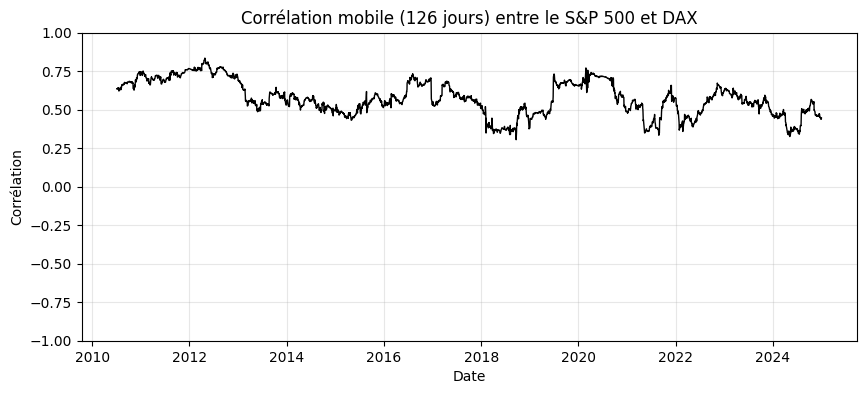

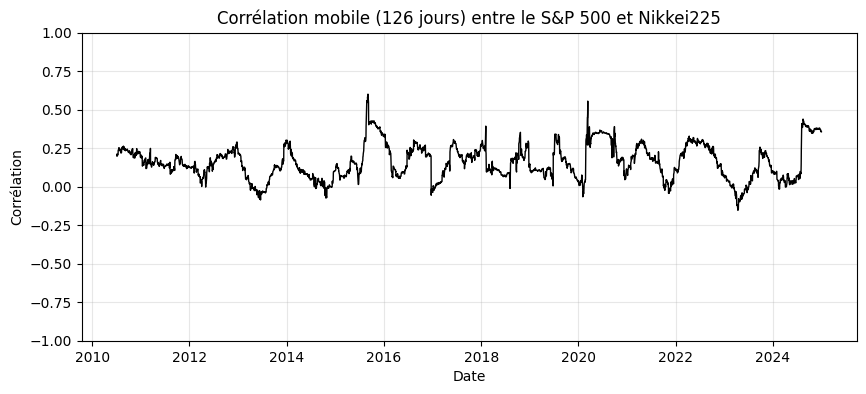

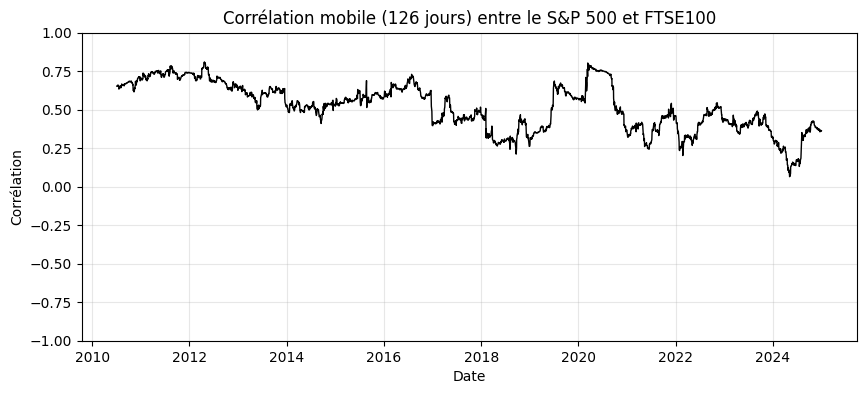

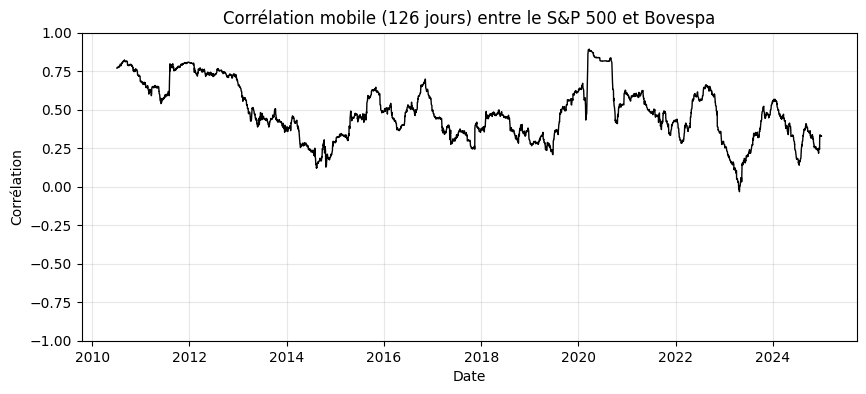

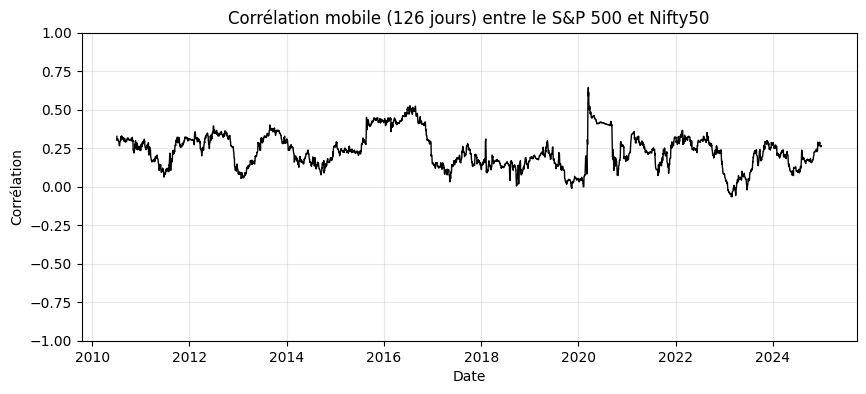

In [17]:
# Graphique corrélations mobiles
plt.figure(figsize=(12,6))
for col in corr_mob.columns:
    plt.figure(figsize=(10,4))
    plt.plot(corr_mob.index, corr_mob[col], color='black', linewidth=1)
    plt.title(f"Corrélation mobile (126 jours) entre le S&P 500 et {col.replace('corr_SP500_', '')}")
    plt.xlabel("Date")
    plt.ylabel("Corrélation")
    plt.grid(alpha=0.3)
    plt.ylim(-1, 1)
    plt.show()

In [19]:
# Importation VIX
vix_query = """
SELECT
    date AS datadate,
    vix AS vix_value
FROM cboe.cboe
WHERE date >= '2010-01-01'
  AND date <= '2024-12-31'
  AND vix IS NOT NULL
ORDER BY date
"""

df_vix = db.raw_sql(vix_query)
df_vix['datadate'] = pd.to_datetime(df_vix['datadate'])
df_vix = df_vix.set_index('datadate')
df_vix['log_VIX'] = np.log(df_vix['vix_value'])

print(df_vix)

corr_mob_vix = corr_mob.join(df_vix['log_VIX'], how='inner').dropna()

print("\nFusion corrélations et log(VIX) :")
print(corr_mob_vix)

            vix_value   log_VIX
datadate                       
2010-01-04      20.04   2.99773
2010-01-05      19.35  2.962692
2010-01-06      19.16  2.952825
2010-01-07      19.06  2.947592
2010-01-08      18.13  2.897568
...               ...       ...
2024-12-24      14.27  2.658159
2024-12-26      14.73  2.689886
2024-12-27      15.95  2.769459
2024-12-30       17.4   2.85647
2024-12-31      17.35  2.853593

[3793 rows x 2 columns]

Fusion corrélations et log(VIX) :
            corr_SP500_DAX  corr_SP500_Nikkei225  corr_SP500_FTSE100  \
2010-07-06        0.635893              0.210762            0.652437   
2010-07-07        0.633235              0.197942            0.651739   
2010-07-08        0.634284              0.206302            0.653415   
2010-07-09        0.635668              0.208772            0.654471   
2010-07-12        0.635538              0.207499            0.653911   
...                    ...                   ...                 ...   
2024-12-24        0.

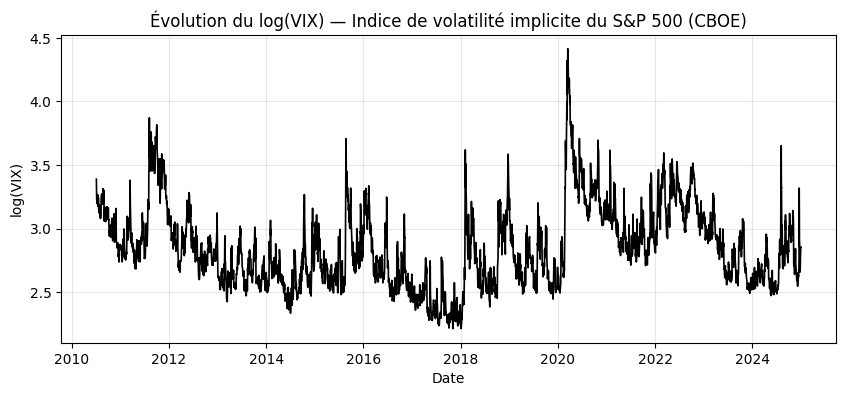

In [20]:
# Graphique log(VIX)
plt.figure(figsize=(10,4))
plt.plot(corr_mob_vix.index, corr_mob_vix['log_VIX'], color='black', linewidth=1.2)
plt.title("Évolution du log(VIX) — Indice de volatilité implicite du S&P 500 (CBOE)")
plt.xlabel("Date")
plt.ylabel("log(VIX)")
plt.grid(alpha=0.3)
plt.show()

In [22]:
# Calcul statistiques descriptives
def acf1(x):
    x = x.dropna()
    return x.autocorr(lag=1)

desc = corr_mob_vix.agg(['mean','std','min','max'])
q = corr_mob_vix.quantile([0.05,0.50,0.95])
acf1_vals = corr_mob_vix.apply(acf1)

print("Statistiques descriptives pour chaque corrélation:")
print(desc.round(3))

print("\nQuantiles (5%, 50%, 95%) :")
print(q.round(3))

print("\nAutocorrélation au lag 1 :")
print(acf1_vals.round(3))

Statistiques descriptives pour chaque corrélation:
      corr_SP500_DAX  corr_SP500_Nikkei225  corr_SP500_FTSE100  \
mean           0.574                 0.160               0.517   
std            0.111                 0.112               0.153   
min            0.305                -0.153               0.065   
max            0.835                 0.601               0.810   

      corr_SP500_Bovespa  corr_SP500_Nifty50  log_VIX  
mean               0.483               0.231    2.846  
std                0.182               0.114    0.319  
min               -0.032              -0.065    2.213  
max                0.893               0.645    4.415  

Quantiles (5%, 50%, 95%) :
      corr_SP500_DAX  corr_SP500_Nikkei225  corr_SP500_FTSE100  \
0.05           0.375                -0.012               0.274   
0.50           0.565                 0.150               0.525   
0.95           0.751                 0.361               0.747   

      corr_SP500_Bovespa  corr_SP500_Nifty50 

In [25]:
# Nettoyage : assurer même nombre d'observations pour chaque série
corr_mob_clean = corr_mob.dropna(how='any')
print(f" {len(corr_mob_clean)} observations pour toutes les séries")

 3647 observations pour toutes les séries


In [92]:
# Test de Dickey-Fuller Augmenté (ADF)
def adf_summary(series):
    s = series.dropna()
    res = adfuller(s, regression='c', autolag='AIC')  
    out = {
        'ADF_stat': res[0],
        'p_value':  res[1],
        'lags':     res[2],
        'n_obs':    len(s),
        'Interprétation': 'Stationnaire' if res[1] < 0.05 else 'Non-stationnaire'
    }
    return pd.Series(out)

adf_table = corr_mob_clean.apply(adf_summary).T

print("RÉSULTATS TEST ADF (Dickey-Fuller Augmenté)")
print(adf_table.round(4))

RÉSULTATS TEST ADF (Dickey-Fuller Augmenté)
                      ADF_stat   p_value lags n_obs    Interprétation
corr_SP500_DAX       -3.087255  0.027511   17  3647      Stationnaire
corr_SP500_Nikkei225 -4.366951  0.000339   13  3647      Stationnaire
corr_SP500_FTSE100   -2.378747  0.147825    3  3647  Non-stationnaire
corr_SP500_Bovespa   -3.048849  0.030578    6  3647      Stationnaire
corr_SP500_Nifty50   -3.854658  0.002395    8  3647      Stationnaire


In [91]:
# Test KPSS complémentaire
def kpss_summary(series):
    s = series.dropna()
    res = kpss(s, regression='c', nlags='auto')
    out = {
        'KPSS_stat': res[0],
        'p_value': res[1],
        'lags': res[2],
        'n_obs': len(s),
        'Interprétation': 'Stationnaire' if res[1] > 0.05 else 'Non-stationnaire'
    }
    return pd.Series(out)

kpss_table = corr_mob_clean.apply(kpss_summary).T

print("RÉSULTATS TEST KPSS (COMPLÉMENT)")
print(kpss_table.round(4))


RÉSULTATS TEST KPSS (COMPLÉMENT)
                     KPSS_stat   p_value lags n_obs    Interprétation
corr_SP500_DAX        2.533298      0.01   38  3647  Non-stationnaire
corr_SP500_Nikkei225  0.181811       0.1   38  3647      Stationnaire
corr_SP500_FTSE100    4.736911      0.01   38  3647  Non-stationnaire
corr_SP500_Bovespa    1.724129      0.01   38  3647  Non-stationnaire
corr_SP500_Nifty50    0.686996  0.014728   38  3647  Non-stationnaire


In [33]:
# Tableau comparatif ADF vs KPSS
comparison_table = pd.DataFrame(index=adf_table.index)

# ADF
comparison_table['ADF_stat'] = adf_table['ADF_stat']
comparison_table['ADF_p_value'] = adf_table['p_value']
comparison_table['ADF_Interprétation'] = adf_table['Interprétation']

# KPSS
comparison_table['KPSS_stat'] = kpss_table['KPSS_stat']
comparison_table['KPSS_p_value'] = kpss_table['p_value']
comparison_table['KPSS_Interprétation'] = kpss_table['Interprétation']

# Décision finale
def final_stationarity_decision(row):
    adf_reject = row['ADF_p_value'] < 0.05  
    kpss_accept = row['KPSS_p_value'] > 0.05 
    
    if adf_reject and kpss_accept:
        return 'Stationnaire'
    elif (not adf_reject) and (not kpss_accept):
        return 'Non-stationnaire'
    else:
        return 'Ambigu'

comparison_table['Décision Finale'] = comparison_table.apply(final_stationarity_decision, axis=1)

print("RÉSUMÉ : TESTS DE STATIONNARITÉ (ADF vs KPSS)")
print(comparison_table.round(4).to_string())



RÉSUMÉ : TESTS DE STATIONNARITÉ (ADF vs KPSS)
                      ADF_stat ADF_p_value ADF_Interprétation KPSS_stat KPSS_p_value KPSS_Interprétation   Décision Finale
corr_SP500_DAX       -3.087255    0.027511       Stationnaire  2.533298         0.01    Non-stationnaire            Ambigu
corr_SP500_Nikkei225 -4.366951    0.000339       Stationnaire  0.181811          0.1        Stationnaire      Stationnaire
corr_SP500_FTSE100   -2.378747    0.147825   Non-stationnaire  4.736911         0.01    Non-stationnaire  Non-stationnaire
corr_SP500_Bovespa   -3.048849    0.030578       Stationnaire  1.724129         0.01    Non-stationnaire            Ambigu
corr_SP500_Nifty50   -3.854658    0.002395       Stationnaire  0.686996     0.014728    Non-stationnaire            Ambigu


# PARTIE 2.2

In [111]:
# Split train/test : 80% train, 20% test 
# Test: centré sur COVID, train: avant + après période COVID - permet de voir effet plus claire période de crise

n_total = len(corr_mob_clean)
covid_start = pd.Timestamp('2020-01-01')

# Taille échantillon test (20% du total)
test_size = int(n_total * 0.20)

# Trouver COVID
covid_idx = corr_mob_clean.index.searchsorted(covid_start)

# Centrer test autour de COVID
# Prendre test_size/2 avant et après COVID
test_start_idx = covid_idx - test_size // 2
test_end_idx = test_start_idx + test_size

# Ajuster si dépasse  bornes
if test_start_idx < 0:
    test_start_idx = 0
    test_end_idx = test_size
elif test_end_idx > n_total:
    test_end_idx = n_total
    test_start_idx = n_total - test_size

# Créer train/test
train_before = corr_mob_clean.iloc[:test_start_idx]
test_data = corr_mob_clean.iloc[test_start_idx:test_end_idx]
train_after = corr_mob_clean.iloc[test_end_idx:]

train_data = pd.concat([train_before, train_after])

print(f"\nÉchantillon Training : {len(train_data)} observations ({len(train_data)/n_total*100:.1f}%)")
print(f"    Partie 1 (avant test) : {len(train_before)} observations allant de {train_before.index[0].date()} à {train_before.index[-1].date()}")
print(f"    Partie 2 (après test) : {len(train_after)} observations allant de {train_after.index[0].date()} à {train_after.index[-1].date()}")
print(f"\nÉchantillon Test : {len(test_data)} observations ({len(test_data)/n_total*100:.1f}%)")
print(f"    Période : de {test_data.index[0].date()} à {test_data.index[-1].date()}")
print(f"\nNombre Observations Totales : {n_total}")



Échantillon Training : 2918 observations (80.0%)
    Partie 1 (avant test) : 2026 observations allant de 2010-07-06 à 2018-07-20
    Partie 2 (après test) : 892 observations allant de 2021-06-16 à 2024-12-31

Échantillon Test : 729 observations (20.0%)
    Période : de 2018-07-23 à 2021-06-15

Nombre Observations Totales : 3647


In [59]:
# HQIC pour trouver p optimal AR(p)
def select_ar_order(series, max_p=10):
    hqic_values = {}
    
    for p in range(1, max_p + 1):
        try:
            model = AutoReg(series, lags=p, old_names=False)
            results = model.fit()
            hqic_values[p] = results.hqic
        except:
            hqic_values[p] = np.inf
    
    p_optimal = min(hqic_values, key=hqic_values.get)
    
    return p_optimal, hqic_values

print("SÉLECTION DE L'ORDRE OPTIMAL AR(p) AVEC HQIC")

# Tableau recap
results_selection = []

for col in train_data.columns:
    serie_name = col.replace('corr_SP500_', '')
    test_series = train_data[col].dropna()
    p_opt, hqic_dict = select_ar_order(test_series, max_p=10)
    
    row = {
        'Série': serie_name,
        'AR(p) optimal': p_opt,
        'HQIC optimal': hqic_dict[p_opt]
    }
    
    results_selection.append(row)

df_selection = pd.DataFrame(results_selection)

print(df_selection.to_string(index=False))

SÉLECTION DE L'ORDRE OPTIMAL AR(p) AVEC HQIC
    Série  AR(p) optimal  HQIC optimal
      DAX              1 -18415.795093
Nikkei225              1 -16155.397658
  FTSE100              1 -17925.046689
  Bovespa              4 -17940.916228
  Nifty50              1 -17005.799347


In [43]:
# Estimation modèle AR + calcul RMSE (définir fonction)
def estimate_ar_model(train_series, test_series, p, in_differences=False):
    # Transformer en différences si nécessaire
    if in_differences:
        train_transformed = train_series.diff().dropna()
        test_transformed = test_series.diff().dropna()
    else:
        train_transformed = train_series
        test_transformed = test_series
    
    # Estimation du modèle AR(p)
    model = AutoReg(train_transformed, lags=p, old_names=False)
    results = model.fit()
    
    # Prévisions one-step-ahead sur le test set
    forecasts = []
    lower_bounds = []
    upper_bounds = []
    
    for i in range(len(test_transformed)):
        if i == 0:
            history = train_transformed.copy()
        else:
            history = pd.concat([train_transformed, test_transformed.iloc[:i]])
        
        # Réestimer le modèle sur historique complet (rolling)
        model_rolling = AutoReg(history, lags=p, old_names=False)
        results_rolling = model_rolling.fit()
        
        # Prévision one-step-ahead
        forecast = results_rolling.forecast(steps=1)
        forecasts.append(forecast.values[0])
        
        # Intervalle de confiance à 95%
        pred_summary = results_rolling.get_prediction(start=len(history), end=len(history))
        pred_df = pred_summary.summary_frame(alpha=0.05)
        lower_bounds.append(pred_df['mean_ci_lower'].values[0])
        upper_bounds.append(pred_df['mean_ci_upper'].values[0])
    
    forecasts = np.array(forecasts)
    lower_bounds = np.array(lower_bounds)
    upper_bounds = np.array(upper_bounds)
    
    # Si en différences, reconvertir en niveaux pour le calcul du RMSE
    if in_differences:
        forecasts_level = []
        lower_level = []
        upper_level = []
        for i in range(len(test_transformed)):
            if i == 0:
                base = train_series.iloc[-1]
            else:
                # Utiliser test_series avec l'index ajusté
                base = test_series.iloc[i]
            forecasts_level.append(base + forecasts[i])
            lower_level.append(base + lower_bounds[i])
            upper_level.append(base + upper_bounds[i])
        
        forecasts_level = np.array(forecasts_level)
        lower_level = np.array(lower_level)
        upper_level = np.array(upper_level)
        actuals = test_series.iloc[1:len(test_transformed)+1].values
    else:
        forecasts_level = forecasts
        lower_level = lower_bounds
        upper_level = upper_bounds
        actuals = test_series.values
    
    # Calcul RMSE sur test
    rmse_test = np.sqrt(mean_squared_error(actuals, forecasts_level))
    
    # Calcul RMSE sur train 
    fitted_values = results.fittedvalues
    if in_differences:
        # Reconvertir les fitted values en niveaux
        fitted_level = []
        for i in range(len(fitted_values)):
            base = train_series.iloc[i]
            fitted_level.append(base + fitted_values.iloc[i])
        fitted_level = np.array(fitted_level)
        train_actuals = train_series.iloc[1:len(fitted_values)+1].values
    else:
        fitted_level = fitted_values.values
        train_actuals = train_series.iloc[:len(fitted_values)].values
    
    rmse_train = np.sqrt(mean_squared_error(train_actuals, fitted_level))
    
    # Calcul couverture (% de valeurs dans IC 95%)
    within_ci = np.sum((actuals >= lower_level) & (actuals <= upper_level))
    coverage = within_ci / len(actuals) * 100
    
    # Coefficients et Std errors
    coefficients = results.params
    std_errors = results.bse
    
    # R² et R² ajusté (sur entraînement)
    fitted_train = results.fittedvalues
    actuals_train = train_transformed[fitted_train.index]
    ss_res = np.sum((actuals_train - fitted_train) ** 2)
    ss_tot = np.sum((actuals_train - actuals_train.mean()) ** 2)
    rsquared = 1 - (ss_res / ss_tot)
    
    # R² ajusté
    n = len(actuals_train)
    k = p + 1  
    rsquared_adj = 1 - ((1 - rsquared) * (n - 1) / (n - k - 1))
    
    result_dict = {
        'p': p,
        'coefficients': coefficients,
        'std_errors': std_errors,
        'rsquared': rsquared,
        'rsquared_adj': rsquared_adj,
        'rmse': rmse_test,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test,
        'coverage': coverage,
        'forecasts': forecasts_level,
        'lower_ci': lower_level,
        'upper_ci': upper_level,
        'actuals': actuals,
        'in_differences': in_differences
    }
    
    # Si en différences, ajouter aussi les prévisions en différences pour les graphiques
    if in_differences:
        result_dict['forecasts_diff'] = forecasts
        result_dict['lower_ci_diff'] = lower_bounds
        result_dict['upper_ci_diff'] = upper_bounds
        result_dict['actuals_diff'] = test_transformed.values
    
    return result_dict

In [58]:
# Déterminer modèles optimaux pour chaque série

results_dict = {}
comparison_rows = []

for col in corr_mob_clean.columns:
    serie_name = col.replace('corr_SP500_', '')
    
    # Extraire train et test pour série
    train_series = train_data[col].dropna()
    test_series = test_data[col].dropna()
    
    # Récupérer stationnarité
    decision = comparison_table.loc[col, 'Décision Finale']

    row = {
        'Série': serie_name,
        'Stationnarité': decision,
        'RMSE (niveaux)': None,
        'RMSE (différences)': None,
        'Approche optimale': None,
        'p optimal': None,
        'RMSE optimal': None
    }
    
    # Détermination modèle optimal selon stationnarité
    if 'Stationnaire' in decision and 'Ambigu' not in decision:

        # Série stationnaire : modéliser en niveaux uniquement
        p_level, _ = select_ar_order(train_series, max_p=10)
        result_level = estimate_ar_model(train_series, test_series, p_level, in_differences=False)
        
        row['RMSE (niveaux)'] = result_level['rmse']
        row['Approche optimale'] = 'Niveaux'
        row['p optimal'] = p_level
        row['RMSE optimal'] = result_level['rmse']
        
        results_dict[serie_name] = result_level
        
    elif 'Non-stationnaire' in decision and 'Ambigu' not in decision:
        # Série non-stationnaire : modéliser en différences uniquement
        train_diff = train_series.diff().dropna()
        p_diff, _ = select_ar_order(train_diff, max_p=10)
        result_diff = estimate_ar_model(train_series, test_series, p_diff, in_differences=True)
        
        row['RMSE (différences)'] = result_diff['rmse']
        row['Approche optimale'] = 'Différences'
        row['p optimal'] = p_diff
        row['RMSE optimal'] = result_diff['rmse']
        
        results_dict[serie_name] = result_diff
        
    else:
        # Série ambigue : tester les DEUX approches et choisir le meilleur RMSE

        # Approche 1 : Niveaux
        p_level, _ = select_ar_order(train_series, max_p=10)
        result_level = estimate_ar_model(train_series, test_series, p_level, in_differences=False)
        
        # Approche 2 : Différences
        train_diff = train_series.diff().dropna()
        p_diff, _ = select_ar_order(train_diff, max_p=10)
        result_diff = estimate_ar_model(train_series, test_series, p_diff, in_differences=True)
        
        row['RMSE (niveaux)'] = result_level['rmse']
        row['RMSE (différences)'] = result_diff['rmse']
        
        # Choisir le modèle avec le meilleur RMSE
        if result_level['rmse'] < result_diff['rmse']:
            row['Approche optimale'] = 'Niveaux'
            row['p optimal'] = p_level
            row['RMSE optimal'] = result_level['rmse']
            results_dict[serie_name] = result_level
        else:
            row['Approche optimale'] = 'Différences'
            row['p optimal'] = p_diff
            row['RMSE optimal'] = result_diff['rmse']
            results_dict[serie_name] = result_diff
    
    comparison_rows.append(row)

df_comparison = pd.DataFrame(comparison_rows)

print("TABLEAU COMPARATIF : NIVEAUX VS DIFFÉRENCES")
print(df_comparison.to_string(index=False))


TABLEAU COMPARATIF : NIVEAUX VS DIFFÉRENCES
    Série    Stationnarité  RMSE (niveaux)  RMSE (différences) Approche optimale  p optimal  RMSE optimal
      DAX           Ambigu        0.014301            0.014339           Niveaux          1      0.014301
Nikkei225     Stationnaire        0.027178                 NaN           Niveaux          1      0.027178
  FTSE100 Non-stationnaire             NaN            0.013980       Différences          1      0.013980
  Bovespa           Ambigu        0.013816            0.013908           Niveaux          4      0.013816
  Nifty50           Ambigu        0.020486            0.020572           Niveaux          1      0.020486


In [90]:
# Coefficients estimés des modèles AR et leurs std errors

coeff_rows = []

for serie_name, result in results_dict.items():
    p = result['p']
    coeffs = result['coefficients']
    std_errs = result['std_errors']
    r_squared = result['rsquared']
    r_squared_adj = result['rsquared_adj']
    
    row = {
        'Série': serie_name,
        'Ordre p': p,
        'R²': r_squared,
        'R² ajusté': r_squared_adj
    }
    
    for i in range(1, 5):
        coeff_found = None
        for coeff_name in coeffs.index:
            if f'.L{i}' in coeff_name:
                coeff_found = coeff_name
                break
        
        if coeff_found and i <= p:
            row[f'AR({i})'] = coeffs[coeff_found]
            row[f'SE AR({i})'] = std_errs[coeff_found]
        else:
            row[f'AR({i})'] = None
            row[f'SE AR({i})'] = None
    
    # Ajouter constante et SE constante
    if 'const' in coeffs.index:
        row['Constante'] = coeffs['const']
        row['SE Const'] = std_errs['const']
    else:
        row['Constante'] = None
        row['SE Const'] = None
    
    coeff_rows.append(row)

coeff_df = pd.DataFrame(coeff_rows)
ordered_cols = ['Série', 'Ordre p', 'R²', 'R² ajusté', 'AR(1)', 'SE AR(1)', 'Constante', 'SE Const', 
                'AR(2)', 'SE AR(2)', 'AR(3)', 'SE AR(3)', 'AR(4)', 'SE AR(4)']
coeff_df = coeff_df[ordered_cols]


print("COEFFICIENTS ESTIMÉS DES MODÈLES AR")
print(coeff_df.to_string(index=False))


COEFFICIENTS ESTIMÉS DES MODÈLES AR
    Série  Ordre p       R²  R² ajusté    AR(1)  SE AR(1)  Constante  SE Const   AR(2)  SE AR(2)    AR(3)  SE AR(3)     AR(4)  SE AR(4)
      DAX        1 0.991233   0.991227 0.995788  0.001734   0.002354  0.001014     NaN       NaN      NaN       NaN       NaN       NaN
Nikkei225        1 0.981864   0.981851 0.991415  0.002495   0.001346  0.000470     NaN       NaN      NaN       NaN       NaN       NaN
  FTSE100        1 0.000066  -0.000621 0.008122  0.018518  -0.000098  0.000207     NaN       NaN      NaN       NaN       NaN       NaN
  Bovespa        4 0.996182   0.996175 0.987855  0.018430   0.001105  0.000580 0.08544  0.025968 0.025334  0.025969 -0.101234  0.018423
  Nifty50        1 0.985548   0.985538 0.992642  0.002226   0.001716  0.000579     NaN       NaN      NaN       NaN       NaN       NaN


In [57]:
# RMSE optimal et couverture

perf_rows = []

for serie_name, result in results_dict.items():
    approach = "Différences" if result['in_differences'] else "Niveaux"
    
    row = {
        'Série': serie_name,
        'Approche': approach,
        'RMSE': result['rmse'],
        'Couverture 95%': result['coverage']
    }
    
    perf_rows.append(row)

perf_df = pd.DataFrame(perf_rows)

print("PERFORMANCE DES MODÈLES")
print(perf_df.to_string(index=False))

PERFORMANCE DES MODÈLES
    Série    Approche     RMSE  Couverture 95%
      DAX     Niveaux 0.014301       92.592593
Nikkei225     Niveaux 0.027178       92.729767
  FTSE100 Différences 0.013980       92.994505
  Bovespa     Niveaux 0.013816       93.689986
  Nifty50     Niveaux 0.020486       91.632373


In [89]:
# Comparaison RMSE Train vs Test

comparison_rmse_rows = []

for serie_name, result in results_dict.items():
    approach = "Différences" if result['in_differences'] else "Niveaux"
    
    rmse_train = result['rmse_train']
    rmse_test = result['rmse_test']
    ratio = rmse_test / rmse_train
    
    # Interprétation
    if ratio < 0.95:
        interpretation = 'Surapprentissage'
    elif ratio <= 1.15:
        interpretation = 'Bonne généralisation'
    else:
        interpretation = 'Sous-apprentissage'
    
    row = {
        'Série': serie_name,
        'Approche': approach,
        'RMSE Train': rmse_train,
        'RMSE Test': rmse_test,
        'Interprétation': interpretation
    }
    
    comparison_rmse_rows.append(row)

comparison_rmse_df = pd.DataFrame(comparison_rmse_rows)

print("COMPARAISON RMSE : TRAIN VS TEST")
print(comparison_rmse_df.to_string(index=False))


COMPARAISON RMSE : TRAIN VS TEST
    Série    Approche  RMSE Train  RMSE Test     Interprétation
      DAX     Niveaux    0.000467   0.014301 Sous-apprentissage
Nikkei225     Niveaux    0.000966   0.027178 Sous-apprentissage
  FTSE100 Différences    0.011099   0.013980 Sous-apprentissage
  Bovespa     Niveaux    0.020921   0.013816   Surapprentissage
  Nifty50     Niveaux    0.000802   0.020486 Sous-apprentissage


In [88]:
# Tests état résidus

diagnostic_rows = []

for serie_name, result in results_dict.items():
    train_series = train_data[f'corr_SP500_{serie_name}'].dropna()
    p = result['p']
    in_differences = result['in_differences']
    
    # Transformer données si nécessaire
    if in_differences:
        train_transformed = train_series.diff().dropna()
    else:
        train_transformed = train_series
    
    # Réestimer le modèle pour obtenir les résidus
    model = AutoReg(train_transformed, lags=p, old_names=False)
    fit_result = model.fit()
    residuals = fit_result.resid
    
    # Test Jarque-Bera 
    jb_stat, jb_pvalue = jarque_bera(residuals)
    jb_conclusion = "Normale" if jb_pvalue > 0.05 else "Non-normale"
    
    # Test Ljung-Box 
    lb_test = acorr_ljungbox(residuals, lags=10, return_df=True)
    lb_pvalue = lb_test['lb_pvalue'].iloc[-1]  
    lb_conclusion = "Pas d'autocorr" if lb_pvalue > 0.05 else "Autocorrélation"
    
    row = {
        'Série': serie_name,
        'JB stat': jb_stat,
        'JB p-value': jb_pvalue,
        'Normalité': jb_conclusion,
        'LB p-value': lb_pvalue,
        'Autocorrélation': lb_conclusion
    }
    
    diagnostic_rows.append(row)

diagnostic_df = pd.DataFrame(diagnostic_rows)

print("ÉTAT DES RÉSIDUS : VALIDATION DES HYPOTHÈSES")
print(diagnostic_df.to_string(index=False))


ÉTAT DES RÉSIDUS : VALIDATION DES HYPOTHÈSES
    Série       JB stat  JB p-value   Normalité  LB p-value Autocorrélation
      DAX  30887.628694         0.0 Non-normale    0.211646  Pas d'autocorr
Nikkei225 255162.864775         0.0 Non-normale    0.417375  Pas d'autocorr
  FTSE100  59814.008580         0.0 Non-normale    0.321925  Pas d'autocorr
  Bovespa  58311.199881         0.0 Non-normale    0.001835 Autocorrélation
  Nifty50  19389.971353         0.0 Non-normale    0.102701  Pas d'autocorr


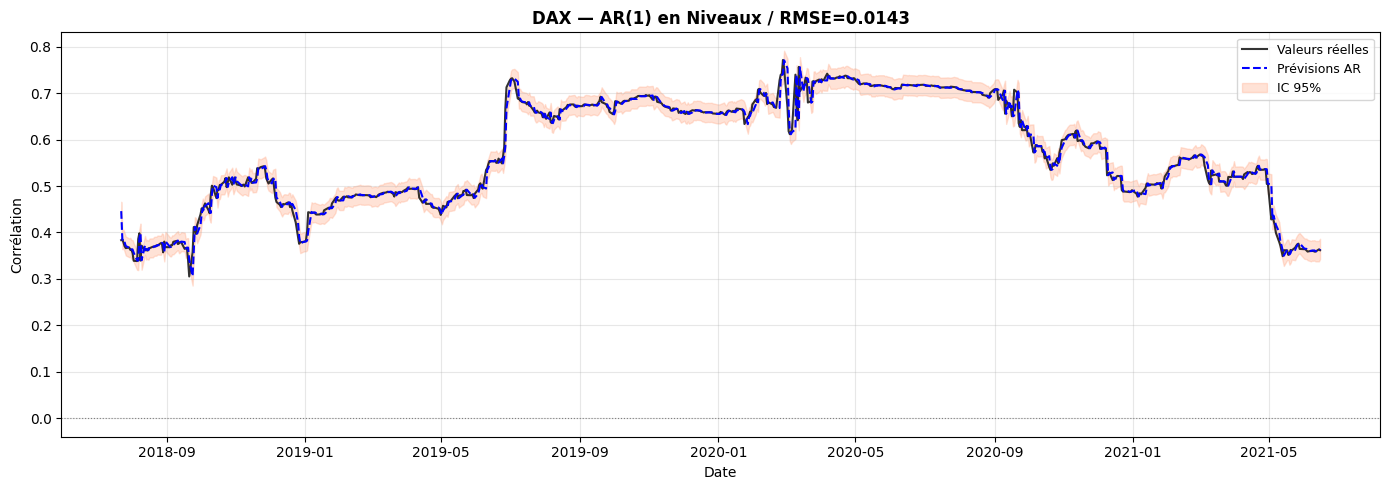

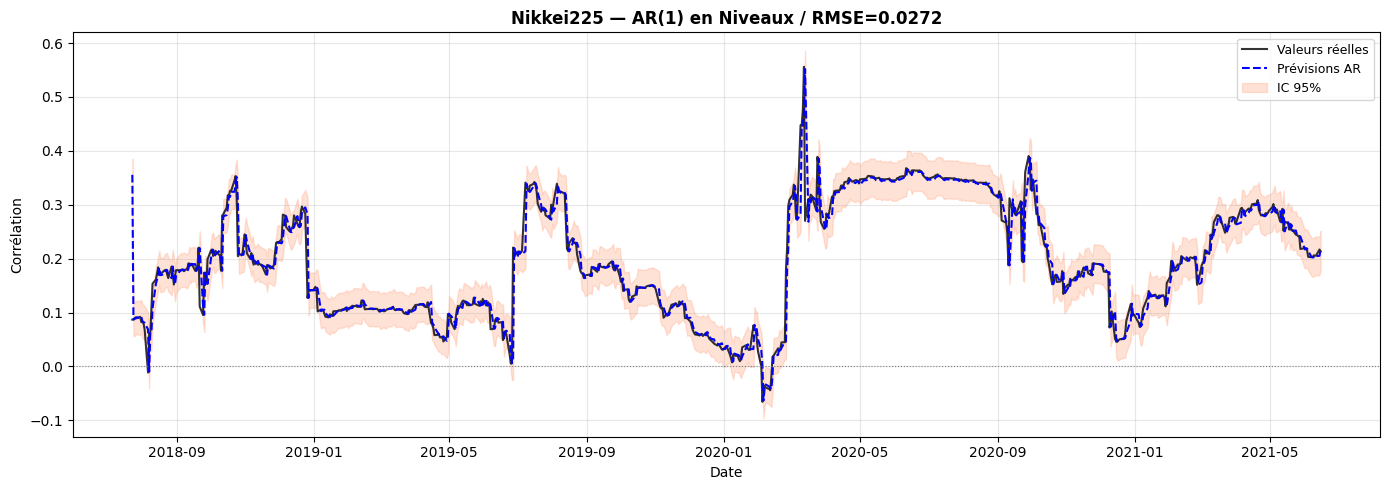

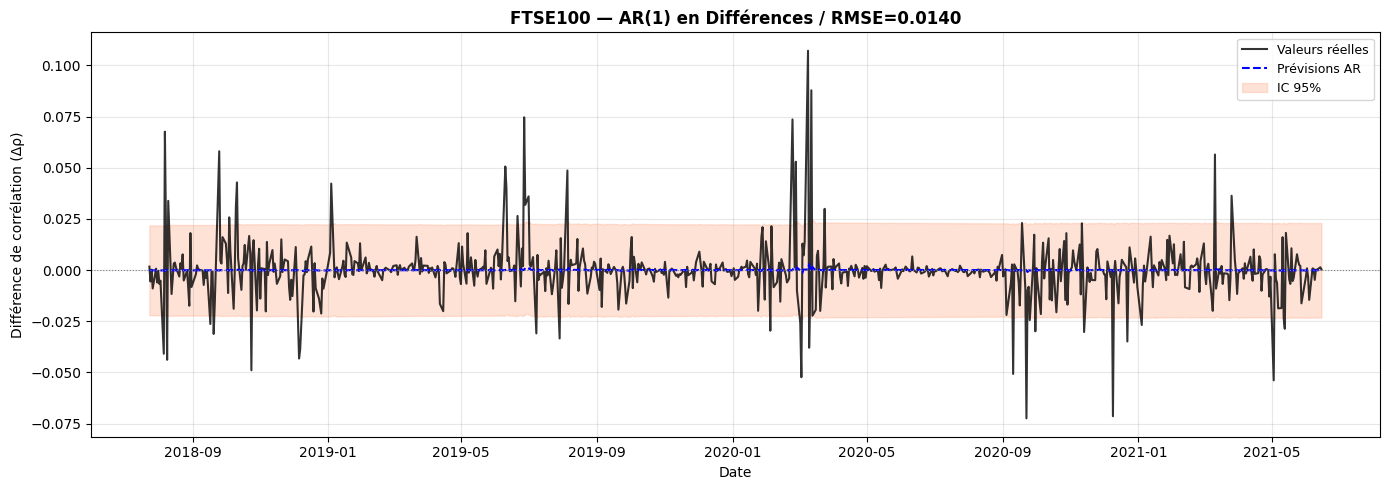

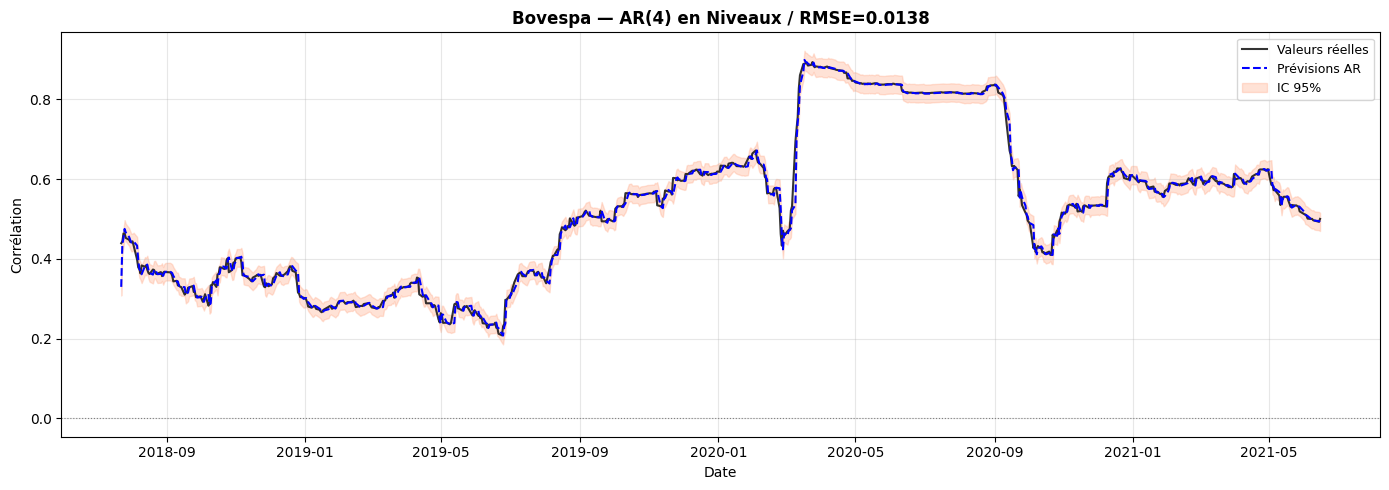

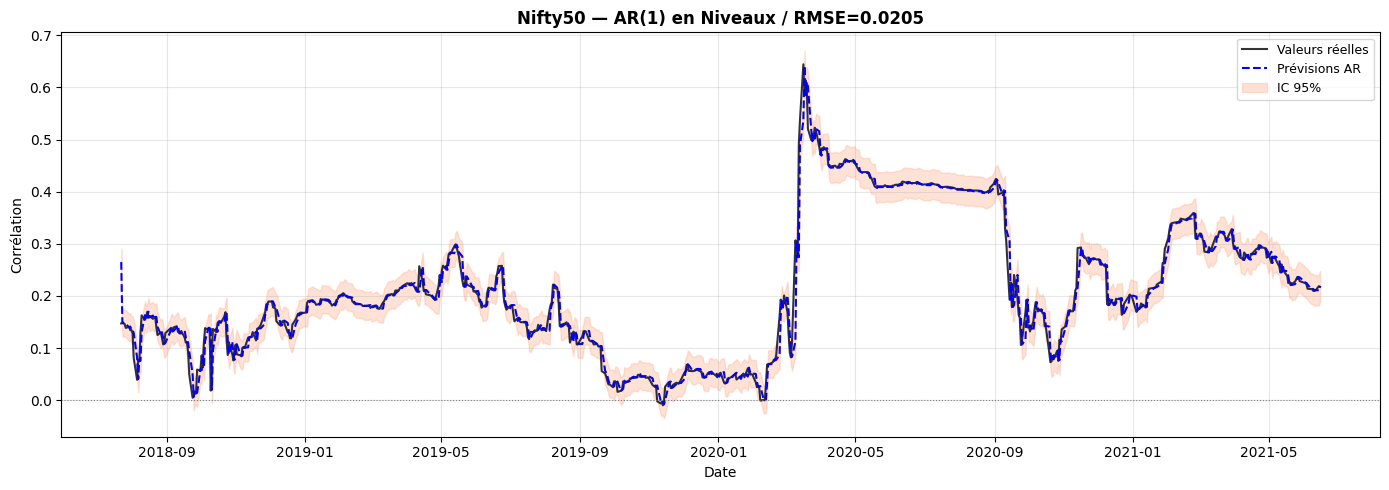

In [69]:
# Graphiques individuels : Prévisions vs Réel avec intervalles de confiance 95%
for serie_name, result in results_dict.items():
    fig, ax = plt.subplots(1, 1, figsize=(14, 5))

    test_series = test_data[f'corr_SP500_{serie_name}'].dropna()
    in_differences = result['in_differences']
    
    if in_differences:
        # Pour modèles en différences 
        actuals_diff = test_series.diff().dropna().values
        forecasts = result['forecasts_diff']
        lower_ci = result['lower_ci_diff']
        upper_ci = result['upper_ci_diff']
        test_dates = test_series.index[1:len(actuals_diff)+1]
        ylabel = 'Différence de corrélation (Δρ)'
    else:
        # Pour modèles en niveaux 
        forecasts = result['forecasts']
        lower_ci = result['lower_ci']
        upper_ci = result['upper_ci']
        actuals_diff = result['actuals']
        test_dates = test_series.index[:len(actuals_diff)]
        ylabel = 'Corrélation'
    
    # Tracer valeurs réelles
    ax.plot(test_dates, actuals_diff, label='Valeurs réelles', 
            color='black', linewidth=1.5, alpha=0.8)
    
    # Tracer prévisions
    ax.plot(test_dates, forecasts, label='Prévisions AR', 
            color='blue', linewidth=1.5, linestyle='--')
    
    # Intervalle de confiance à 95%
    ax.fill_between(test_dates, lower_ci, upper_ci, 
                     color='lightsalmon', alpha=0.3, label='IC 95%')
    
    rmse = result['rmse']
    coverage = result['coverage']
    p = result['p']
    approach = "Différences" if in_differences else "Niveaux"
    
    ax.set_title(f"{serie_name} — AR({p}) en {approach} / RMSE={rmse:.4f}",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.8)
    plt.tight_layout()
    plt.show()


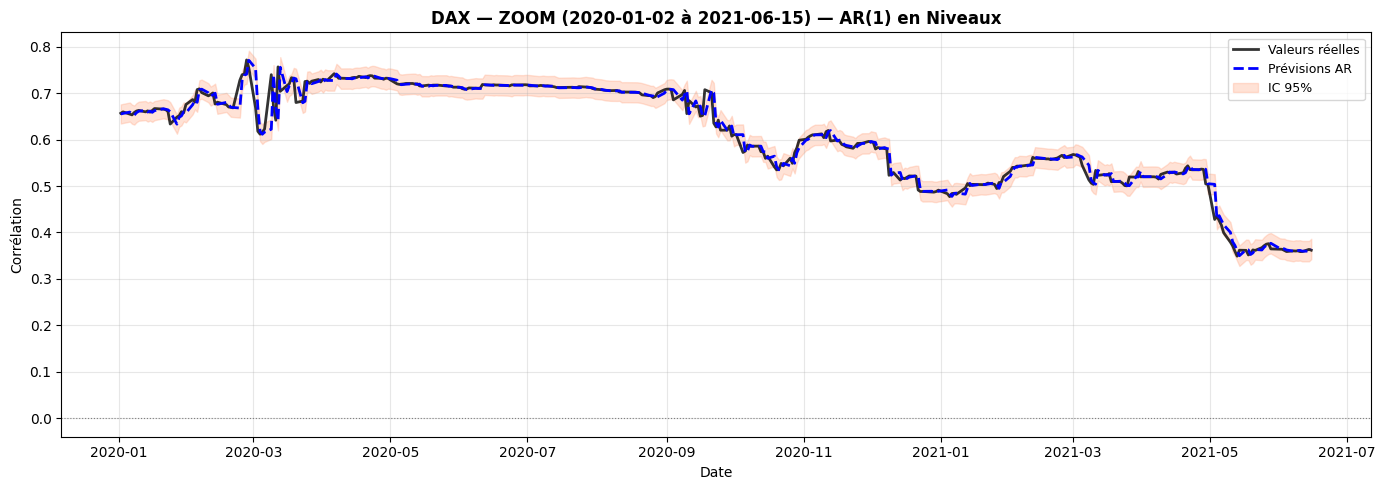

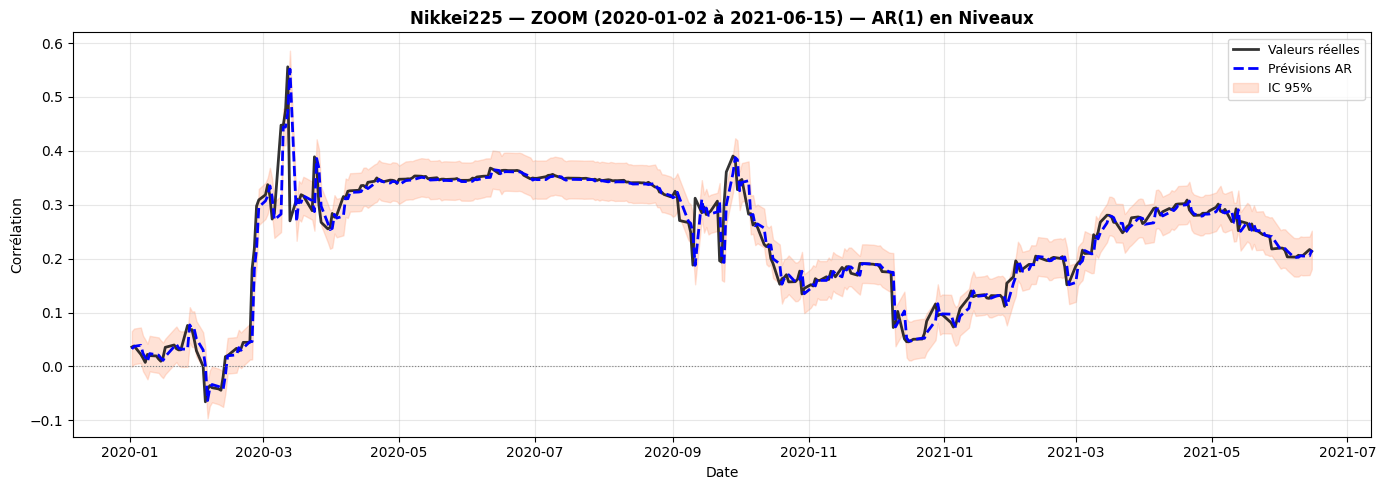

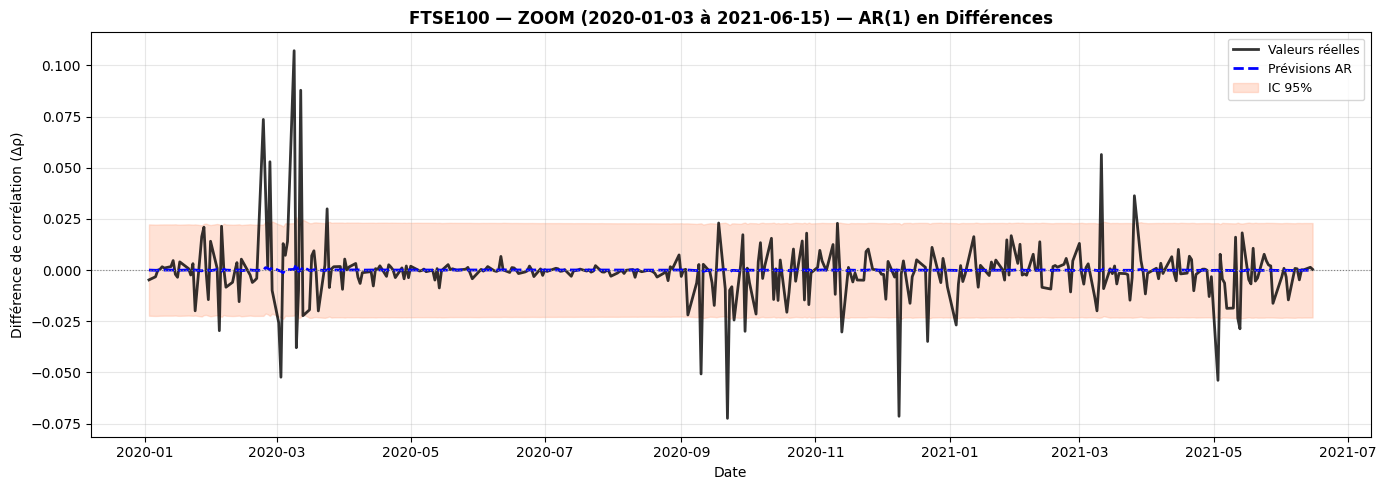

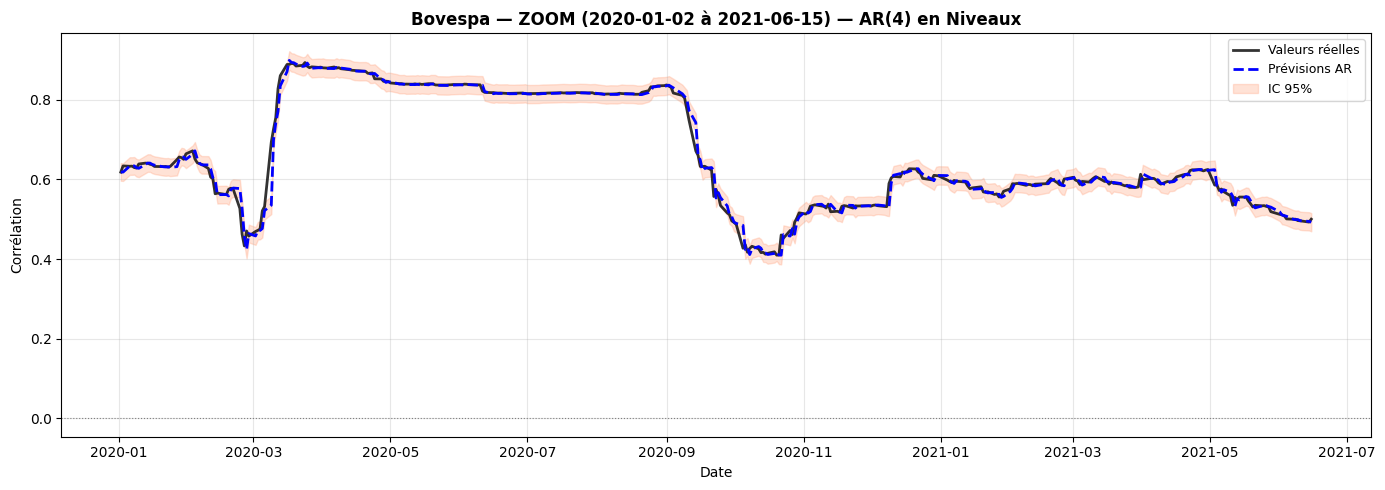

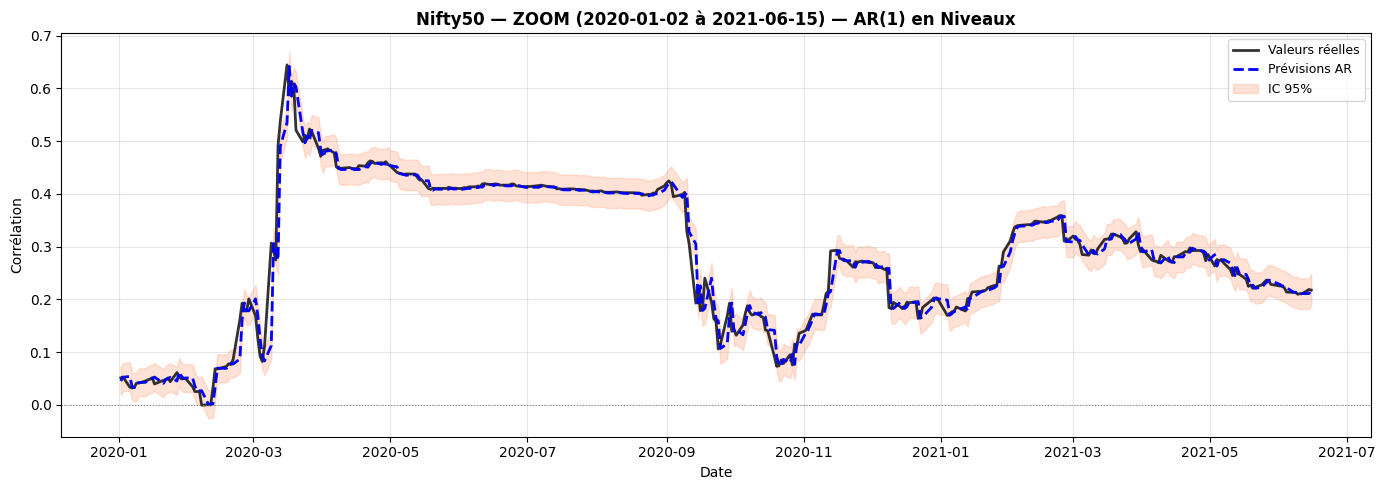

In [110]:
# Graphiques zoomés sur COVID (2020-2021)

for serie_name, result in results_dict.items():
    fig, ax = plt.subplots(1, 1, figsize=(14, 5))
    
    # Récupérer les données
    test_series = test_data[f'corr_SP500_{serie_name}'].dropna()
    in_differences = result['in_differences']
    
    if in_differences:
        # Pour modèles différences 
        actuals_diff = test_series.diff().dropna().values
        forecasts = result['forecasts_diff']
        lower_ci = result['lower_ci_diff']
        upper_ci = result['upper_ci_diff']
        test_dates = test_series.index[1:len(actuals_diff)+1]
        ylabel = 'Différence de corrélation (Δρ)'
    else:
        # Pour modèles niveaux 
        forecasts = result['forecasts']
        lower_ci = result['lower_ci']
        upper_ci = result['upper_ci']
        actuals_diff = result['actuals']
        test_dates = test_series.index[:len(actuals_diff)]
        ylabel = 'Corrélation'
    
    # zoom
    mid_point = len(test_dates) // 2
    zoom_dates = test_dates[mid_point:]
    zoom_actuals = actuals_diff[mid_point:]
    zoom_forecasts = forecasts[mid_point:]
    zoom_lower_ci = lower_ci[mid_point:]
    zoom_upper_ci = upper_ci[mid_point:]
    
    # Tracer les valeurs réelles
    ax.plot(zoom_dates, zoom_actuals, label='Valeurs réelles', 
            color='black', linewidth=2, alpha=0.8)
    
    # Tracer les prévisions
    ax.plot(zoom_dates, zoom_forecasts, label='Prévisions AR', 
            color='blue', linewidth=2, linestyle='--')
    
    # Intervalle de confiance à 95%
    ax.fill_between(zoom_dates, zoom_lower_ci, zoom_upper_ci, 
                     color='lightsalmon', alpha=0.3, label='IC 95%')
    
    rmse = result['rmse']
    coverage = result['coverage']
    p = result['p']
    approach = "Différences" if in_differences else "Niveaux"
    
    ax.set_title(f"{serie_name} — ZOOM ({zoom_dates[0].date()} à {zoom_dates[-1].date()}) — AR({p}) en {approach}",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.8)
    plt.tight_layout()
    plt.show()


# PARTIE 2.3

In [72]:
# Préparation données pour modèles explicatifs
# Fusionner corrélations et VIX sur mêmes dates

explanatory_data = corr_mob_vix.copy()

print(f"Période : {explanatory_data.index[0].date()} à {explanatory_data.index[-1].date()}")
print(f"Nombre d'observations : {len(explanatory_data)}")

# Créer terme quadratique
explanatory_data['log_VIX_squared'] = explanatory_data['log_VIX'] ** 2

print("\nAperçu des données :")
print(explanatory_data[['log_VIX', 'log_VIX_squared']].describe())

Période : 2010-07-06 à 2024-12-31
Nombre d'observations : 3647

Aperçu des données :
        log_VIX  log_VIX_squared
count    3647.0           3647.0
mean   2.845849         8.200371
std    0.318661         1.902145
min     2.21266         4.895866
25%    2.604909         6.785553
50%    2.796671         7.821371
75%    3.041422          9.25025
max    4.415099        19.493096


In [73]:
# Fonction pour estimer modèles linéaire et quadratique
def estimate_explanatory_models(corr_series, vix_data):
    # Fusionner corrélation et VIX
    data = pd.DataFrame({
        'corr': corr_series,
        'log_VIX': vix_data['log_VIX'],
        'log_VIX_squared': vix_data['log_VIX_squared']
    }).dropna()
    
    data = data.astype(float)
    
    # Modèle Linéaire
    X_linear = sm.add_constant(data['log_VIX'])
    model_linear = sm.OLS(data['corr'], X_linear)
    results_linear = model_linear.fit()
    
    # Modèle Quadratique
    X_quad = sm.add_constant(data[['log_VIX', 'log_VIX_squared']])
    model_quad = sm.OLS(data['corr'], X_quad)
    results_quad = model_quad.fit()
    
    # Point de bascule si relation en U
    beta1 = results_quad.params['log_VIX']
    beta2 = results_quad.params['log_VIX_squared']
    
    tipping_point = None
    tipping_vix_level = None
    
    # Relation en U
    if beta1 < 0 and beta2 > 0:
        #log(VIX) = -β1 / (2*β2)
        tipping_point = -beta1 / (2 * beta2)
        tipping_vix_level = np.exp(tipping_point)
    
    return {
        'linear': results_linear,
        'quadratic': results_quad,
        'data': data,
        'tipping_point_log': tipping_point,
        'tipping_vix_level': tipping_vix_level
    }

In [74]:
# Estimation des modèles pour séries
explanatory_results = {}

for col in corr_cols:
    serie_name = col
    
    corr_series = explanatory_data[f'corr_SP500_{col}']
    
    results = estimate_explanatory_models(corr_series, explanatory_data)
    explanatory_results[serie_name] = results

In [87]:
# Données Modèle linéaire avec erreurs-types

linear_rows = []

for serie_name, results in explanatory_results.items():
    linear_model = results['linear']
    
    row = {
        'Marché': serie_name,
        'β₀': linear_model.params['const'],
        'SE(β₀)': linear_model.bse['const'],
        'β₁': linear_model.params['log_VIX'],
        'SE(β₁)': linear_model.bse['log_VIX'],
        'p-value β₁': linear_model.pvalues['log_VIX'],
        'R²': linear_model.rsquared,
        'R² ajusté': linear_model.rsquared_adj,
        'Observations': int(linear_model.nobs)
    }
    
    linear_rows.append(row)

linear_df = pd.DataFrame(linear_rows)

print("TABLEAU RÉCAPITULATIF MODÈLE LINÉAIRE")
print(linear_df.to_string(index=False))


TABLEAU RÉCAPITULATIF MODÈLE LINÉAIRE
   Marché        β₀   SE(β₀)       β₁   SE(β₁)    p-value β₁       R²  R² ajusté  Observations
      DAX  0.367069 0.016194 0.072680 0.005655  5.244165e-37 0.043353   0.043091          3647
Nikkei225 -0.164448 0.015844 0.114091 0.005533  1.877694e-89 0.104473   0.104228          3647
  FTSE100  0.219788 0.022151 0.104519 0.007735  1.248821e-40 0.047698   0.047437          3647
  Bovespa -0.262386 0.024148 0.261974 0.008433 3.395289e-188 0.209356   0.209139          3647
  Nifty50 -0.059415 0.016212 0.102181 0.005661  8.114616e-70 0.082040   0.081788          3647


In [84]:
# Données Modèle quadratique avec erreurs-types

quad_rows = []

for serie_name, results in explanatory_results.items():
    quad_model = results['quadratic']
    
    row = {
        'Marché': serie_name,
        'β₀': quad_model.params['const'],
        'SE(β₀)': quad_model.bse['const'],
        'β₁': quad_model.params['log_VIX'],
        'SE(β₁)': quad_model.bse['log_VIX'],
        'p-value β₁': quad_model.pvalues['log_VIX'],
        'β₂': quad_model.params['log_VIX_squared'],
        'SE(β₂)': quad_model.bse['log_VIX_squared'],
        'p-value β₂': quad_model.pvalues['log_VIX_squared'],
        'R²': quad_model.rsquared,
        'R² ajusté': quad_model.rsquared_adj,
        'Observations': int(quad_model.nobs)
    }
    
    quad_rows.append(row)

quad_df = pd.DataFrame(quad_rows)

print("TABLEAU RÉCAPITULATIF MODÈLE QUADRATIQUE")
print(quad_df.to_string(index=False))


TABLEAU RÉCAPITULATIF MODÈLE QUADRATIQUE
   Marché       β₀   SE(β₀)        β₁   SE(β₁)  p-value β₁       β₂   SE(β₂)   p-value β₂       R²  R² ajusté  Observations
      DAX 0.796858 0.104172 -0.220167 0.070348    0.001764 0.049218 0.011785 3.032423e-05 0.047910   0.047388          3647
Nikkei225 0.442887 0.101655 -0.299731 0.068648    0.000013 0.069550 0.011500 1.618121e-09 0.113372   0.112886          3647
  FTSE100 0.790916 0.142517 -0.284633 0.096242    0.003122 0.065404 0.016123 5.084725e-05 0.051979   0.051459          3647
  Bovespa 0.025848 0.155635  0.065579 0.105101    0.532690 0.033008 0.017607 6.091733e-02 0.210117   0.209684          3647
  Nifty50 0.308710 0.104357 -0.148649 0.070473    0.034985 0.042157 0.011806 3.605360e-04 0.085240   0.084738          3647


In [93]:
# Comparaison Linéaire VS Quadratique

comparison_expl_rows = []

for serie_name, results in explanatory_results.items():
    linear_model = results['linear']
    quad_model = results['quadratic']
    
    # Déterminer si relation en U
    beta1 = quad_model.params['log_VIX']
    beta2 = quad_model.params['log_VIX_squared']
    beta2_pval = quad_model.pvalues['log_VIX_squared']
    
    u_shape = "Oui" if (beta1 < 0 and beta2 > 0 and beta2_pval < 0.05) else "Non"
    
    # Amélioration du R²
    delta_r2 = quad_model.rsquared - linear_model.rsquared
    delta_r2_adj = quad_model.rsquared_adj - linear_model.rsquared_adj
    
    # Meilleur modèle selon AIC (plus bas = meilleur)
    best_model = "Quadratique" if quad_model.aic < linear_model.aic else "Linéaire"
    
    row = {
        'Marché': serie_name,
        'R² Linéaire': linear_model.rsquared,
        'R² Quadratique': quad_model.rsquared,
        'Différence R²': delta_r2,
        'Différence R² ajusté': delta_r2_adj,
        'β₂ significatif': "Oui" if beta2_pval < 0.05 else "Non",
        'Relation en U': u_shape,
        'Meilleur modèle': best_model
    }
    
    comparison_expl_rows.append(row)

comparison_expl_df = pd.DataFrame(comparison_expl_rows)

print("COMPARAISON : MODÈLE LINÉAIRE VS QUADRATIQUE")
print(comparison_expl_df.to_string(index=False))


COMPARAISON : MODÈLE LINÉAIRE VS QUADRATIQUE
   Marché  R² Linéaire  R² Quadratique  Différence R²  Différence R² ajusté β₂ significatif Relation en U Meilleur modèle
      DAX     0.043353        0.047910       0.004557              0.004297             Oui           Oui     Quadratique
Nikkei225     0.104473        0.113372       0.008899              0.008658             Oui           Oui     Quadratique
  FTSE100     0.047698        0.051979       0.004281              0.004022             Oui           Oui     Quadratique
  Bovespa     0.209356        0.210117       0.000762              0.000545             Non           Non     Quadratique
  Nifty50     0.082040        0.085240       0.003201              0.002951             Oui           Oui     Quadratique


In [82]:
# Points de bascule pour relations en U

tipping_rows = []

for serie_name, results in explanatory_results.items():
    quad_model = results['quadratic']
    beta1 = quad_model.params['log_VIX']
    beta2 = quad_model.params['log_VIX_squared']
    beta2_pval = quad_model.pvalues['log_VIX_squared']
    
    tipping_log = results['tipping_point_log']
    tipping_vix = results['tipping_vix_level']
    
    # Créer ligne pour tous les marchés
    row = {
        'Marché': serie_name,
        'β₁': beta1,
        'β₂': beta2,
        'p-value β₂': beta2_pval,
        'log(VIX) bascule': tipping_log if (tipping_log is not None and beta2_pval < 0.05) else None,
        'VIX bascule': tipping_vix if (tipping_log is not None and beta2_pval < 0.05) else None,
        'Relation en U': 'Oui' if (beta1 < 0 and beta2 > 0 and beta2_pval < 0.05) else 'Non'
    }
    
    tipping_rows.append(row)

tipping_df = pd.DataFrame(tipping_rows)

print("POINTS DE BASCULE")
print(tipping_df.to_string(index=False))


POINTS DE BASCULE
   Marché        β₁       β₂   p-value β₂  log(VIX) bascule  VIX bascule Relation en U
      DAX -0.220167 0.049218 3.032423e-05          2.236634     9.361762           Oui
Nikkei225 -0.299731 0.069550 1.618121e-09          2.154771     8.625914           Oui
  FTSE100 -0.284633 0.065404 5.084725e-05          2.175952     8.810566           Oui
  Bovespa  0.065579 0.033008 6.091733e-02               NaN          NaN           Non
  Nifty50 -0.148649 0.042157 3.605360e-04          1.763058     5.830236           Oui


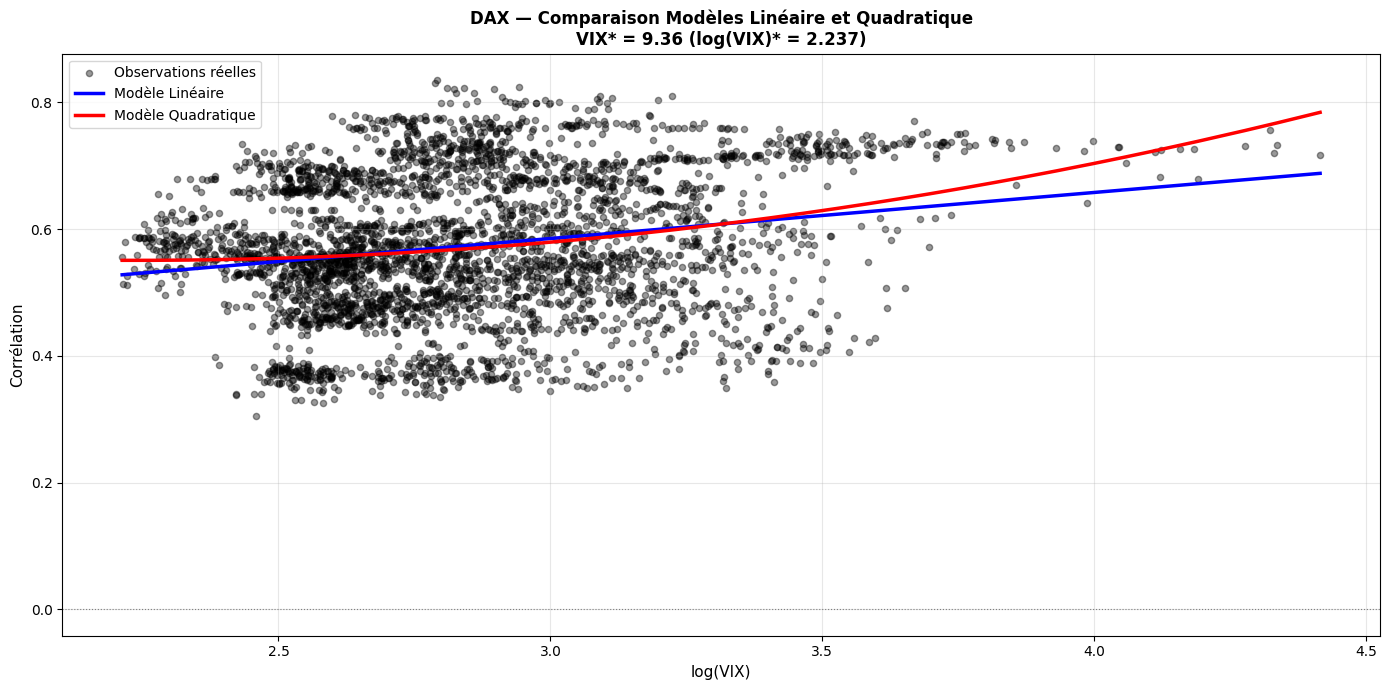

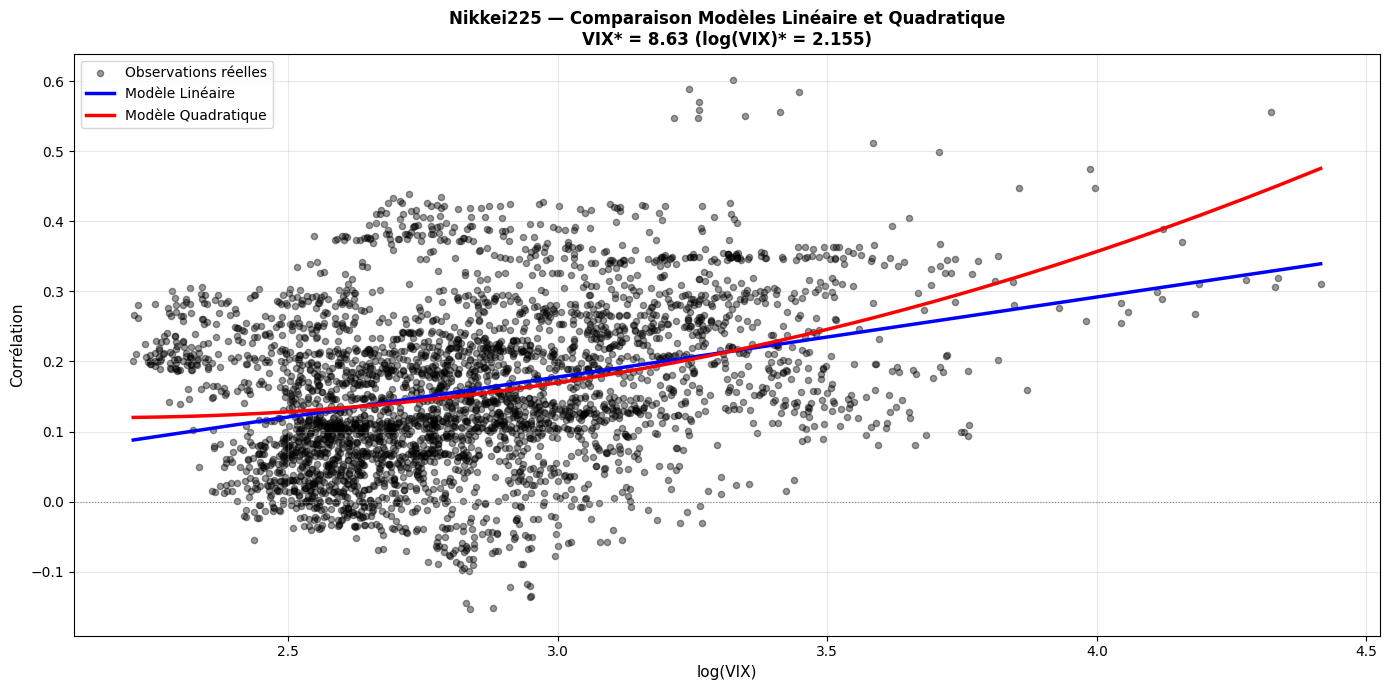

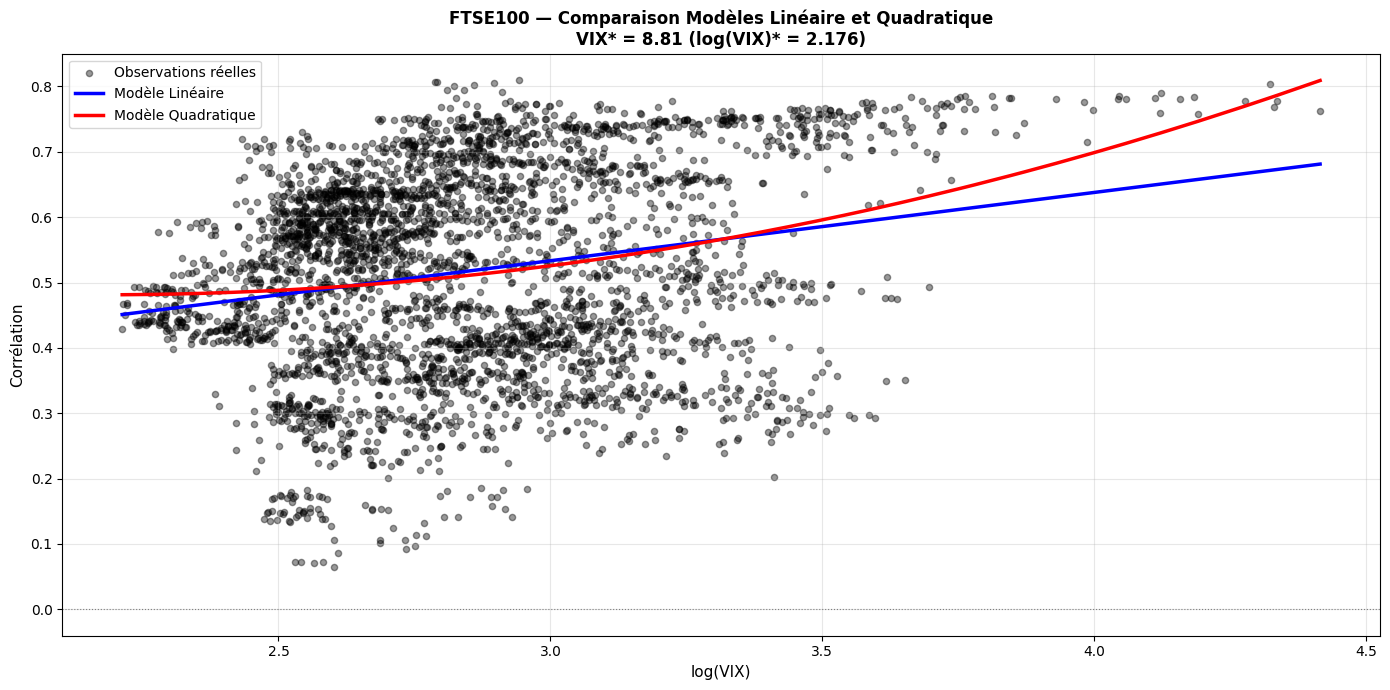

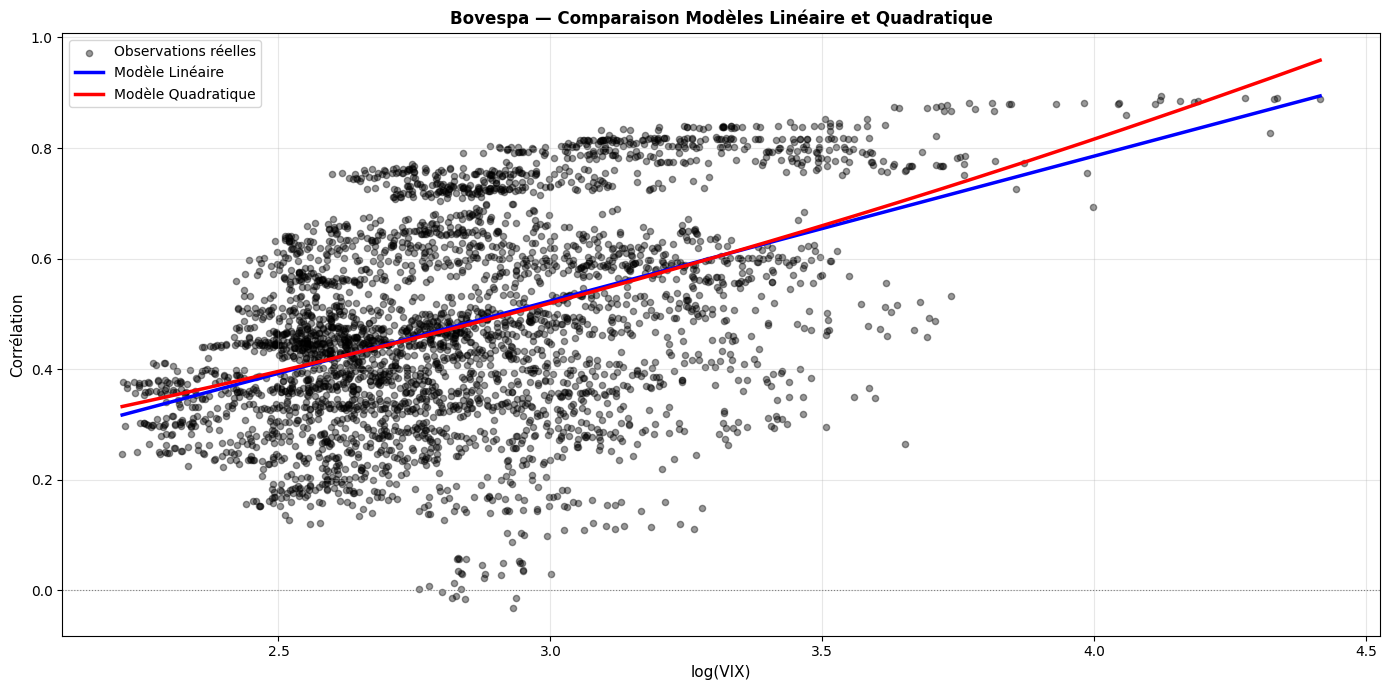

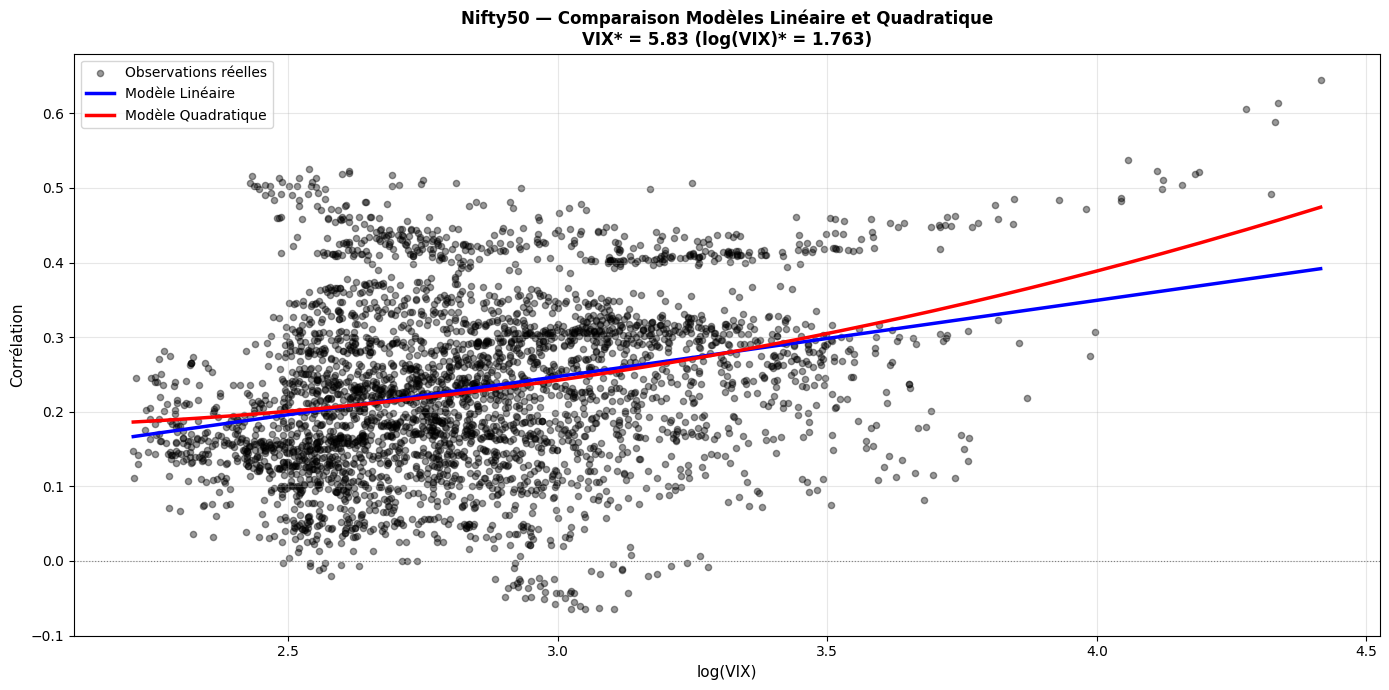

In [95]:
# Graphiques : Modèles Linéaire ET Quadratique superposés

for serie_name, results in explanatory_results.items():
    linear_model = results['linear']
    quad_model = results['quadratic']
    data = results['data']
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Trier pour tracer lignes propres
    sorted_idx = data['log_VIX'].argsort()
    
    # Observations réelles
    ax.scatter(data['log_VIX'], data['corr'], alpha=0.4, s=20, color='black', 
               label='Observations réelles', zorder=1)
    
    # Modèle Linéaire
    ax.plot(data['log_VIX'].iloc[sorted_idx], linear_model.fittedvalues.iloc[sorted_idx], 
            color='blue', linewidth=2.5, label=f'Modèle Linéaire', 
            zorder=3)
    
    # Modèle Quadratique
    ax.plot(data['log_VIX'].iloc[sorted_idx], quad_model.fittedvalues.iloc[sorted_idx], 
            color='red', linewidth=2.5, label=f'Modèle Quadratique', 
            zorder=4)
    
    # Point de bascule si relation en U
    beta1 = quad_model.params['log_VIX']
    beta2 = quad_model.params['log_VIX_squared']
    beta2_pval = quad_model.pvalues['log_VIX_squared']
    
    title = f"{serie_name} — Comparaison Modèles Linéaire et Quadratique"
    
    if beta1 < 0 and beta2 > 0 and beta2_pval < 0.05:
        tipping_log = results['tipping_point_log']
        tipping_vix = results['tipping_vix_level']
        title += f"\nVIX* = {tipping_vix:.2f} (log(VIX)* = {tipping_log:.3f})"
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('log(VIX)', fontsize=11)
    ax.set_ylabel('Corrélation', fontsize=11)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.8)
    
    plt.tight_layout()
    plt.show()


# PARTIE 2.4 

In [96]:
# Préparation des données ARX avec VIX décalé 
# Fusionner corrélations et VIX
arx_data = corr_mob_clean.join(df_vix['log_VIX'], how='inner').dropna()

# Variables VIX décalées 
arx_data['log_VIX_lag1'] = arx_data['log_VIX'].shift(1)
arx_data['log_VIX_squared_lag1'] = arx_data['log_VIX_lag1'] ** 2

# Supprimer première ligne (NaN parce que décalé)
arx_data = arx_data.dropna()

print(f"\nPériode : {arx_data.index[0].date()} à {arx_data.index[-1].date()}")
print(f"Nombre d'Observations Totales: {len(arx_data)}")

print("\nVariables exogènes décalées :")
print(arx_data[['log_VIX', 'log_VIX_lag1', 'log_VIX_squared_lag1']].describe())


Période : 2010-07-07 à 2024-12-31
Nombre d'Observations Totales: 3646

Variables exogènes décalées :
        log_VIX  log_VIX_lag1  log_VIX_squared_lag1
count    3646.0        3646.0                3646.0
mean     2.8457      2.845846              8.200387
std    0.318577      0.318705              1.902406
min     2.21266       2.21266              4.895866
25%    2.604909      2.604909              6.785553
50%    2.796671      2.796671              7.821371
75%    3.040945      3.041542              9.250976
max    4.415099      4.415099             19.493096


In [97]:
# Split train/test pour modèles ARX (même que 2.2)

train_idx = train_data.index.intersection(arx_data.index)
test_idx = test_data.index.intersection(arx_data.index)

arx_train = arx_data.loc[train_idx]
arx_test = arx_data.loc[test_idx]

print(f"\nÉchantillon Training : {len(arx_train)} observations")
print(f"  Période : {arx_train.index[0].date()} à {arx_train.index[-1].date()}")

print(f"\nÉchantillon Test : {len(arx_test)} observations")
print(f"  Période : {arx_test.index[0].date()} à {arx_test.index[-1].date()}")


Échantillon Training : 2917 observations
  Période : 2010-07-07 à 2024-12-31

Échantillon Test : 729 observations
  Période : 2018-07-23 à 2021-06-15


In [100]:
# Définir ARX avec variables exogènes

def estimate_arx_model(train_corr, test_corr, train_exog, test_exog, p, include_quadratic=True):
    # Variables exogènes
    if include_quadratic:
        exog_cols = ['log_VIX_lag1', 'log_VIX_squared_lag1']
    else:
        exog_cols = ['log_VIX_lag1']
    
    X_train = train_exog[exog_cols].astype(float)
    X_test = test_exog[exog_cols].astype(float)
    
    # Estimation du modèle ARX une seule fois sur le training set
    model = AutoReg(train_corr, lags=p, exog=X_train, old_names=False)
    results = model.fit()
    
    # Prévisions one-step-ahead sur le test set
    forecasts = []
    lower_bounds = []
    upper_bounds = []
    
    # Récupérer les coefficients
    params = results.params
    
    # Calculer l'erreur standard pour les IC
    residuals_std = np.sqrt(results.sigma2)
    z_critical = 1.96
    
    full_corr = pd.concat([train_corr, test_corr])
    
    for i in range(len(test_corr)):
        current_idx = len(train_corr) + i
        
        # Construire le vecteur X pour la prévision au temps t
        x_vec = []
        
        # Constante (si présente)
        if 'const' in params.index:
            x_vec.append(1.0)
        
        # p dernières valeurs de corrélation
        for lag in range(1, p + 1):
            x_vec.append(full_corr.iloc[current_idx - lag])
        
        # Variables exogènes (VIX décalé et VIX² décalé)
        for col in X_test.columns:
            x_vec.append(X_test.iloc[i][col])
        
        # Calculer prévision 
        x_vec = np.array(x_vec)
        forecast_val = np.dot(x_vec, params.values)
        
        forecasts.append(forecast_val)
        lower_bounds.append(forecast_val - z_critical * residuals_std)
        upper_bounds.append(forecast_val + z_critical * residuals_std)
    
    forecasts = np.array(forecasts)
    lower_bounds = np.array(lower_bounds)
    upper_bounds = np.array(upper_bounds)
    
    forecasts = np.array(forecasts)
    lower_bounds = np.array(lower_bounds)
    upper_bounds = np.array(upper_bounds)
    actuals = test_corr.values
    
    # Calcul RMSE sur test
    rmse_test = np.sqrt(mean_squared_error(actuals, forecasts))
    
    # Calcul RMSE sur train
    fitted_values = results.fittedvalues
    train_actuals = train_corr.iloc[:len(fitted_values)].values
    rmse_train = np.sqrt(mean_squared_error(train_actuals, fitted_values.values))
    
    # Calcul couverture (à 95%)
    within_ci = np.sum((actuals >= lower_bounds) & (actuals <= upper_bounds))
    coverage = within_ci / len(actuals) * 100
    
    # Coefficients et Std errors
    coefficients = results.params
    std_errors = results.bse
    
    # Calculer R² sur train
    fitted_vals = results.fittedvalues.values
    y_train = train_corr.iloc[:len(fitted_vals)].values
    ss_res = np.sum((y_train - fitted_vals) ** 2)
    ss_tot = np.sum((y_train - np.mean(y_train)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    
    result_dict = {
        'p': p,
        'include_quadratic': include_quadratic,
        'coefficients': coefficients,
        'std_errors': std_errors,
        'pvalues': results.pvalues,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test,
        'coverage': coverage,
        'forecasts': forecasts,
        'lower_ci': lower_bounds,
        'upper_ci': upper_bounds,
        'actuals': actuals,
        'aic': results.aic,
        'bic': results.bic,
        'rsquared': r_squared,
        'nobs': len(train_corr)
    }
    
    return result_dict

In [109]:
# Estimer modèles ARX quadratiques pour séries
print("ESTIMATION MODÈLES ARX QUADRATIQUES")

arx_results = {}

for col in corr_cols:
    serie_name = col
    
    print(f"{serie_name}")
    
    # Extraire les données
    train_corr = arx_train[f'corr_SP500_{col}']
    test_corr = arx_test[f'corr_SP500_{col}']
    
    # TRAITEMENT SPÉCIAL FTSE100 : Appliquer les différences premières
    if serie_name == 'FTSE100':
        train_corr = train_corr.diff().dropna()
        test_corr = test_corr.diff().dropna()
        
        # Ajuster aussi les variables exogènes pour correspondre aux indices
        train_exog = arx_train[['log_VIX_lag1', 'log_VIX_squared_lag1']].loc[train_corr.index]
        test_exog = arx_test[['log_VIX_lag1', 'log_VIX_squared_lag1']].loc[test_corr.index]
    else:
        train_exog = arx_train[['log_VIX_lag1', 'log_VIX_squared_lag1']]
        test_exog = arx_test[['log_VIX_lag1', 'log_VIX_squared_lag1']]
    
    # Récupérer l'ordre p optimal de la 2.2
    p_optimal = results_dict[serie_name]['p']
    print(f"Ordre AR optimal (2.2) : p = {p_optimal}")
    
    # Estimer le modèle ARX quadratique (selon 2.3)
    arx_model = estimate_arx_model(train_corr, test_corr, train_exog, test_exog, 
                                    p_optimal, include_quadratic=True)
    
    print(f"Modèle ARX")
    print(f" - RMSE train : {arx_model['rmse_train']:.6f}")
    print(f" - RMSE test  : {arx_model['rmse_test']:.6f}")
    print(f" - R²         : {arx_model['rsquared']:.6f}")
    print(f" - Couverture   : {arx_model['coverage']:.2f}%")
    print()
    
    arx_results[serie_name] = {
        'ar': results_dict[serie_name],  # Modèle AR de référence (2.2)
        'arx': arx_model                 # Modèle ARX quadratique
    }

ESTIMATION MODÈLES ARX QUADRATIQUES
DAX
Ordre AR optimal (2.2) : p = 1
Modèle ARX
 - RMSE train : 0.000805
 - RMSE test  : 0.014347
 - R²         : 0.999946
 - Couverture   : 91.91%

Nikkei225
Ordre AR optimal (2.2) : p = 1
Modèle ARX
 - RMSE train : 0.001002
 - RMSE test  : 0.027175
 - R²         : 0.999921
 - Couverture   : 91.22%

FTSE100
Ordre AR optimal (2.2) : p = 1
Modèle ARX
 - RMSE train : 0.011122
 - RMSE test  : 0.013970
 - R²         : 0.012479
 - Couverture   : 93.27%

Bovespa
Ordre AR optimal (2.2) : p = 4
Modèle ARX
 - RMSE train : 0.020931
 - RMSE test  : 0.013824
 - R²         : 0.986432
 - Couverture   : 93.69%

Nifty50
Ordre AR optimal (2.2) : p = 1
Modèle ARX
 - RMSE train : 0.000884
 - RMSE test  : 0.020559
 - R²         : 0.999934
 - Couverture   : 90.67%



In [108]:
# Tableau comparatif AR VS ARX quadratique

comparison_arx_rows = []

for serie_name, models in arx_results.items():
    ar_model = models['ar']
    arx_model = models['arx']
    
    # Calculer gain de performance
    gain = ((ar_model['rmse_test'] - arx_model['rmse_test']) / ar_model['rmse_test']) * 100
    
    row = {
        'Marché': serie_name,
        'RMSE AR': ar_model['rmse_test'],
        'RMSE ARX': arx_model['rmse_test'],
        'Gains (%)': gain,
        'Couverture AR (%)': ar_model['coverage'],
        'Couverture ARX (%)': arx_model['coverage'],
        'Meilleur modèle': 'ARX' if arx_model['rmse_test'] < ar_model['rmse_test'] else 'AR'
    }
    
    comparison_arx_rows.append(row)

comparison_arx_df = pd.DataFrame(comparison_arx_rows)


print("TABLEAU COMPARATIF: AR VS ARX QUADRATIQUE")
print(comparison_arx_df.to_string(index=False))


TABLEAU COMPARATIF: AR VS ARX QUADRATIQUE
   Marché  RMSE AR  RMSE ARX  Gains (%)  Couverture AR (%)  Couverture ARX (%) Meilleur modèle
      DAX 0.014301  0.014347  -0.315946          92.592593           91.906722              AR
Nikkei225 0.027178  0.027175   0.011835          92.729767           91.220850             ARX
  FTSE100 0.013980  0.013970   0.068803          92.994505           93.269231             ARX
  Bovespa 0.013816  0.013824  -0.054540          93.689986           93.689986              AR
  Nifty50 0.020486  0.020559  -0.360710          91.632373           90.672154              AR


In [112]:
# Coefficients modèle ARX 

coeff_arx_rows = []

for serie_name, models in arx_results.items():
    arx_model = models['arx']
    
    coeffs = arx_model['coefficients']
    std_errs = arx_model['std_errors']
    pvals = arx_model['pvalues']
    
    row = {
        'Marché': serie_name,
        'p': arx_model['p']
    }
    
    # Constante
    if 'const' in coeffs.index:
        row['Const'] = coeffs['const']
        row['p-val Const'] = pvals['const']
    
    # Coefficients AR 
    for i in range(1, min(arx_model['p'] + 1, 5)):
        coeff_name = None
        for name in coeffs.index:
            if f'.L{i}' in name and 'log_VIX' not in name:
                coeff_name = name
                break
        
        if coeff_name and i <= arx_model['p']:
            row[f'AR({i})'] = coeffs[coeff_name]
            row[f'p-val AR({i})'] = pvals[coeff_name]
        else:
            row[f'AR({i})'] = None
            row[f'p-val AR({i})'] = None
    
    # Variables exogènes VIX
    if 'log_VIX_lag1' in coeffs.index:
        row['β_VIX'] = coeffs['log_VIX_lag1']
        row['p-val VIX'] = pvals['log_VIX_lag1']
    
    if 'log_VIX_squared_lag1' in coeffs.index:
        row['β_VIX²'] = coeffs['log_VIX_squared_lag1']
        row['p-val VIX²'] = pvals['log_VIX_squared_lag1']
    
    # Statistiques d'ajustement
    row['R²'] = arx_model['rsquared']
    row['AIC'] = arx_model['aic']
    
    coeff_arx_rows.append(row)

coeff_arx_df = pd.DataFrame(coeff_arx_rows)


print("COEFFICIENTS MODÈLE ARX")
print(coeff_arx_df.to_string(index=False))


COEFFICIENTS MODÈLE ARX
   Marché  p     Const  p-val Const    AR(1)  p-val AR(1)     β_VIX  p-val VIX    β_VIX²  p-val VIX²       R²           AIC    AR(2)  p-val AR(2)   AR(3)  p-val AR(3)     AR(4)  p-val AR(4)
      DAX  1 -0.046081     0.001138 0.995639     0.000000  0.033351   0.000666 -0.005662    0.000788 0.999946 -18422.879899      NaN          NaN     NaN          NaN       NaN          NaN
Nikkei225  1 -0.011722     0.575845 0.991987     0.000000  0.009698   0.504230 -0.001787    0.475197 0.999921 -16152.928302      NaN          NaN     NaN          NaN       NaN          NaN
  FTSE100  1 -0.048610     0.001585 0.008435     0.648281  0.034212   0.001345 -0.005966    0.001159 0.012479 -17920.356379      NaN          NaN     NaN          NaN       NaN          NaN
  Bovespa  4  0.009122     0.551067 0.983368     0.000000 -0.006998   0.509899  0.001529    0.402786 0.986432 -17949.248402 0.085294      0.00101 0.02564     0.323012 -0.098085 1.061501e-07
  Nifty50  1 -0.027103    

In [116]:
# Test de significativité variables VIX (F-test)

ftest_rows = []

for serie_name, models in arx_results.items():
    arx_model = models['arx']
    ar_model = models['ar']
    
    # Récupérer info ARX
    p = arx_model['p']
    n_obs = arx_model['nobs']
    
    # Nombre paramètres 
    k_arx = 1 + p + 2  # Modèle ARX 
    k_ar = 1 + p       # Modèle AR simple (sans VIX)
    
    if 'rsquared' in ar_model:
        r2_ar = ar_model['rsquared']
    else:
        # Calculer R² 
        actuals_ar = ar_model['actuals']
        forecasts_ar = ar_model['forecasts']
        ss_res_ar = np.sum((actuals_ar - forecasts_ar) ** 2)
        ss_tot_ar = np.sum((actuals_ar - np.mean(actuals_ar)) ** 2)
        r2_ar = 1 - (ss_res_ar / ss_tot_ar)
    
    r2_arx = arx_model['rsquared']
    
    q = 2  
    
    numerator = (r2_arx - r2_ar) / q
    denominator = (1 - r2_arx) / (n_obs - k_arx)
    
    f_stat = numerator / denominator
    
    # Degrés de liberté 
    df1 = q
    df2 = n_obs - k_arx
    
    # Calcul p-value
    p_value = 1 - stats.f.cdf(f_stat, df1, df2)
    
    if p_value < 0.05:
        interpretation = "VIX significatif"
    else:
        interpretation = "VIX non significatif"
    
    row = {
        'Marché': serie_name,
        'F-stat': f_stat,
        'p-value': p_value,
        'Interprétation': interpretation,
        'R² AR': r2_ar,
        'R² ARX': r2_arx,
        'Différence R²': r2_arx - r2_ar
    }
    
    ftest_rows.append(row)

ftest_df = pd.DataFrame(ftest_rows)

print("TEST DE SIGNIFICATIVITÉ DES VARIABLES VIX")
print(ftest_df.to_string(index=False))


TEST DE SIGNIFICATIVITÉ DES VARIABLES VIX
   Marché        F-stat      p-value       Interprétation    R² AR   R² ARX  Différence R²
      DAX 236136.379093 1.110223e-16     VIX significatif 0.991233 0.999946       0.008713
Nikkei225 330837.666269 1.110223e-16     VIX significatif 0.981864 0.999921       0.018057
  FTSE100     18.301124 1.263164e-08     VIX significatif 0.000066 0.012479       0.012413
  Bovespa  -1045.514900 1.000000e+00 VIX non significatif 0.996182 0.986432      -0.009749
  Nifty50 318156.477080 1.110223e-16     VIX significatif 0.985548 0.999934       0.014386


In [119]:
# Comparaison AR VS ARX: couverture IC

coverage_arx_rows = []

for serie_name, models in arx_results.items():
    ar_model = models['ar']
    arx_model = models['arx']
    
    row = {
        'Marché': serie_name,
        'Couverture AR (%)': ar_model['coverage'],
        'Couverture ARX (%)': arx_model['coverage'],
        'Écart AR vs 95%': abs(ar_model['coverage'] - 95),
        'Écart ARX vs 95%': abs(arx_model['coverage'] - 95),
        'Meilleur couverture': 'ARX' if abs(arx_model['coverage'] - 95) < abs(ar_model['coverage'] - 95) else 'AR'
    }
    
    coverage_arx_rows.append(row)

coverage_arx_df = pd.DataFrame(coverage_arx_rows)

print("COUVERTURE DES INTERVALLES DE CONFIANCE: AR VS ARX")
print(coverage_arx_df.to_string(index=False))


COUVERTURE DES INTERVALLES DE CONFIANCE: AR VS ARX
   Marché  Couverture AR (%)  Couverture ARX (%)  Écart AR vs 95%  Écart ARX vs 95% Meilleur couverture
      DAX          92.592593           91.906722         2.407407          3.093278                  AR
Nikkei225          92.729767           91.220850         2.270233          3.779150                  AR
  FTSE100          92.994505           93.269231         2.005495          1.730769                 ARX
  Bovespa          93.689986           93.689986         1.310014          1.310014                  AR
  Nifty50          91.632373           90.672154         3.367627          4.327846                  AR


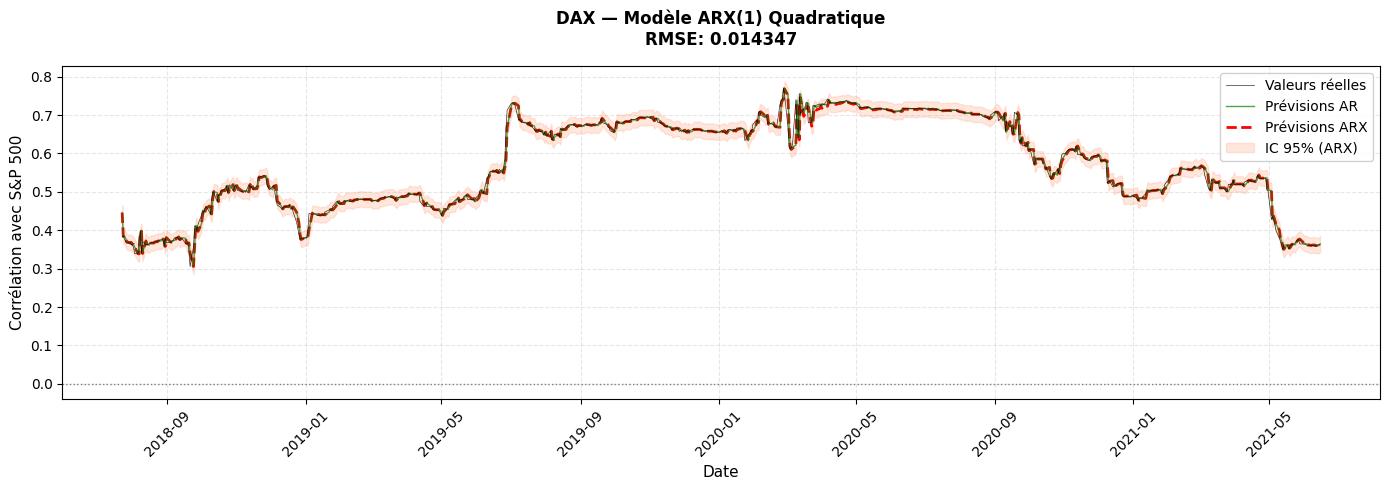

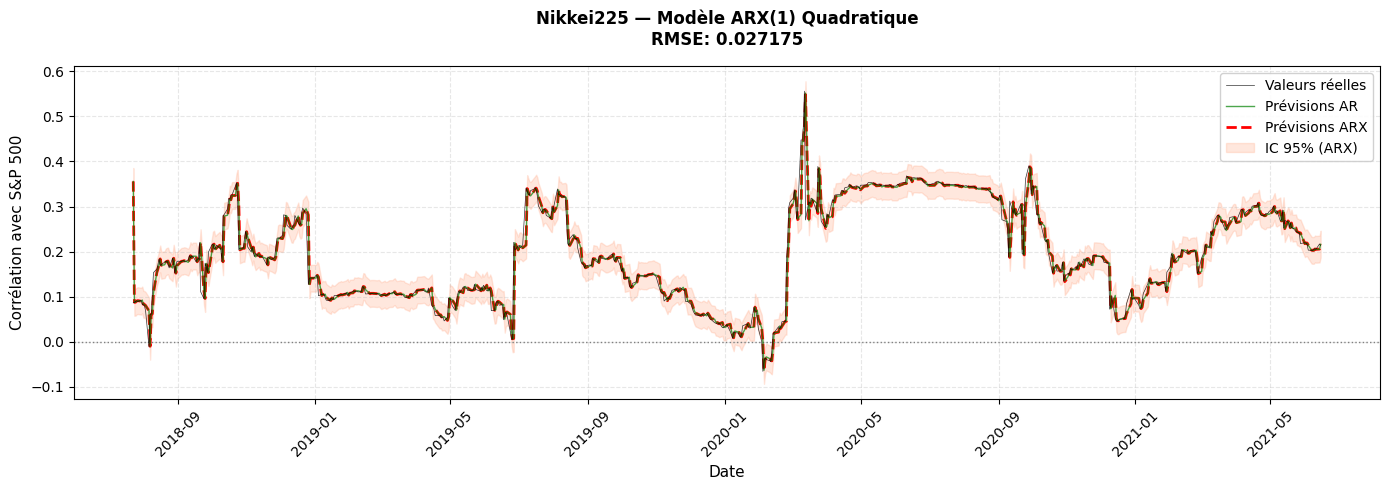

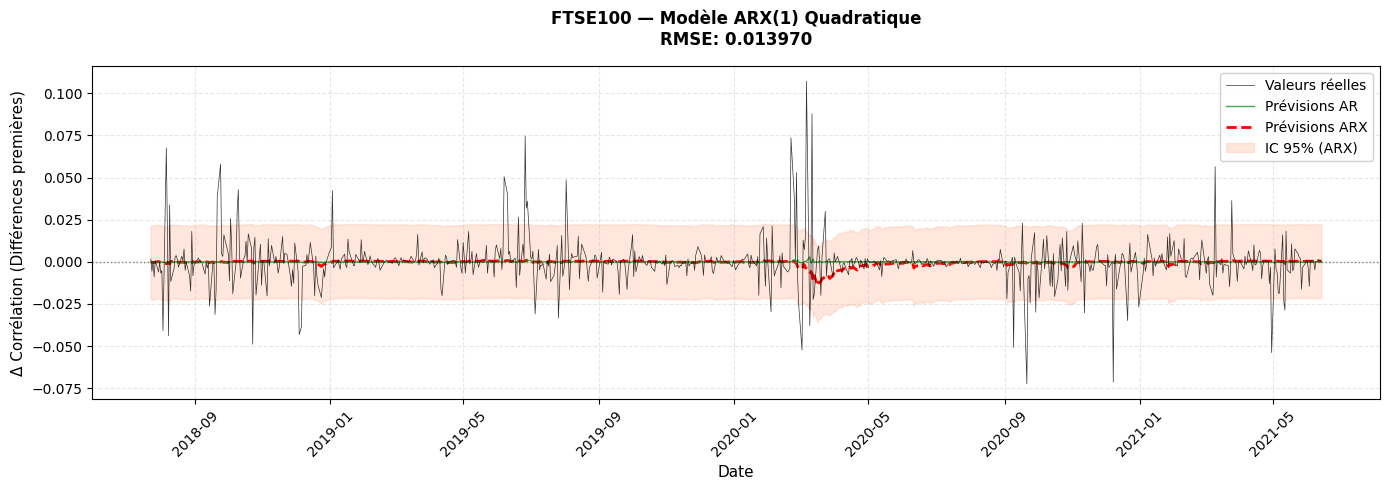

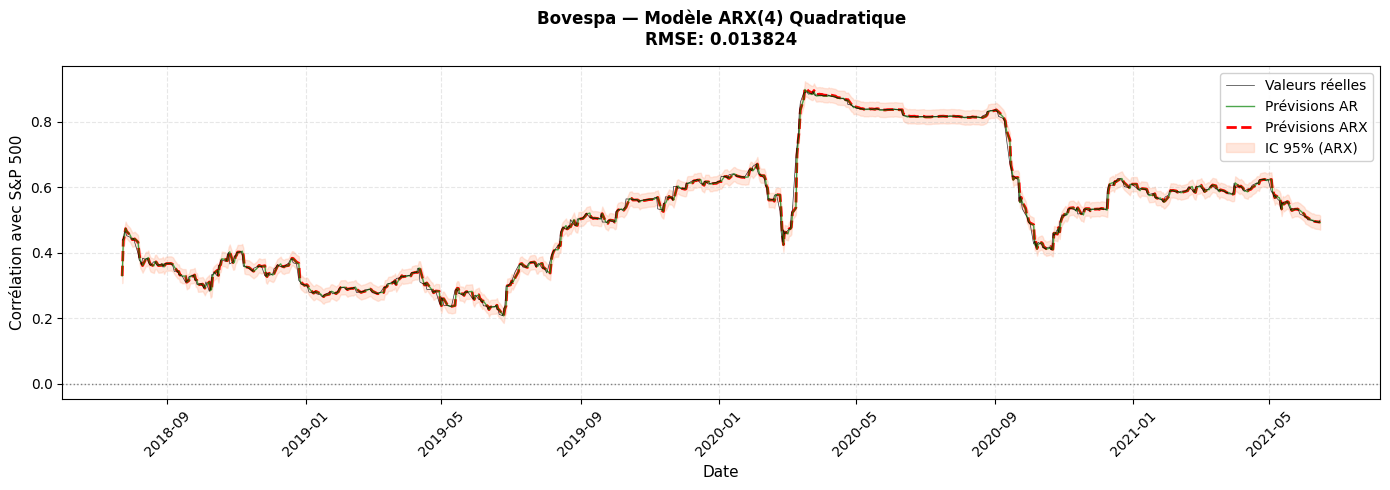

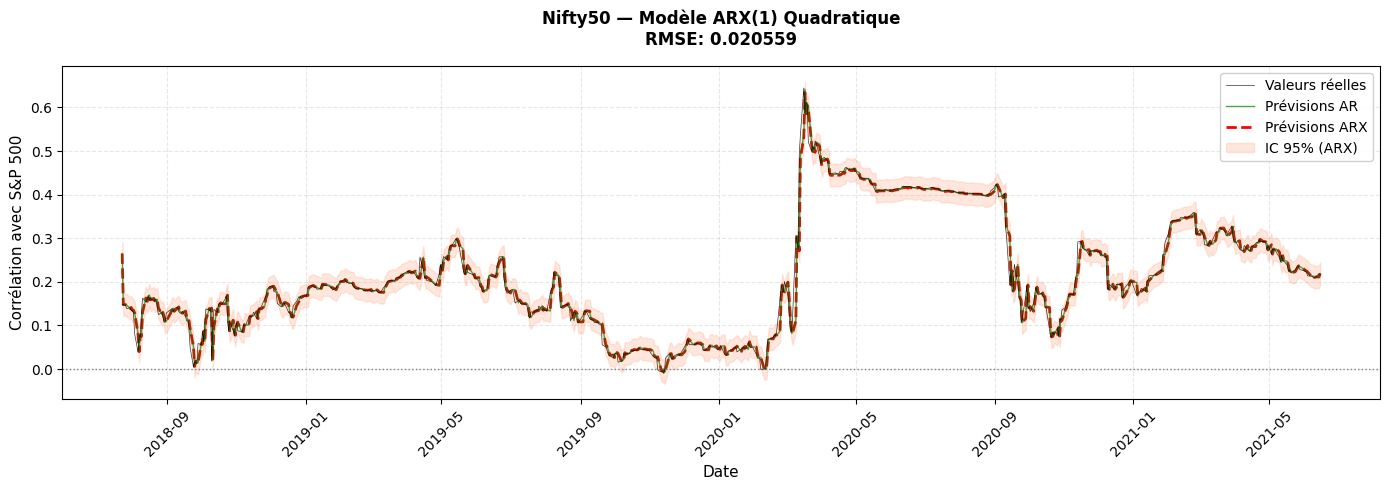

In [127]:
# Graphiques ARX

for serie_name, models in arx_results.items():
    ar_model = models['ar']
    arx_model = models['arx']
    
    # Récupérer données test
    test_corr = arx_test[f'corr_SP500_{serie_name}']
    test_dates = test_corr.index
    
    n_arx = len(arx_model['actuals'])
    test_dates_arx = test_dates[:n_arx]
    
    # Note spéciale pour FTSE100 (modèle en différences)
    if serie_name == 'FTSE100':
        y_label = 'Δ Corrélation (Différences premières)'
        # Pour FTSE100, utiliser les prévisions en différences
        ar_forecasts = ar_model['forecasts_diff'][:n_arx] if 'forecasts_diff' in ar_model else ar_model['forecasts'][:n_arx]
    else:
        note_ftse = ""
        y_label = 'Corrélation avec S&P 500'
        ar_forecasts = ar_model['forecasts'][:n_arx]
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    # Tracer valeurs réelles
    ax.plot(test_dates_arx, arx_model['actuals'], label='Valeurs réelles', 
            color='black', linewidth=0.5, alpha=0.8, zorder=4)
    
    # Tracer prévisions AR 
    ax.plot(test_dates_arx, ar_forecasts, 
            label=f'Prévisions AR', 
            color='green', linewidth=1, linestyle='-', alpha=0.7, zorder=3)
    
    # Tracer prévisions ARX
    ax.plot(test_dates_arx, arx_model['forecasts'], 
            label=f'Prévisions ARX', 
            color='red', linewidth=2, linestyle='--', zorder=2)
    
    # Intervalle de confiance à 95% 
    ax.fill_between(test_dates_arx, arx_model['lower_ci'], arx_model['upper_ci'], 
                    color='lightsalmon', alpha=0.25, label='IC 95% (ARX)', zorder=1)
    
    ax.axhline(y=0, color='gray', linestyle=':', linewidth=1)
    
    ax.set_title(
        f"{serie_name} — Modèle ARX({arx_model['p']}) Quadratique{note_ftse}\n"
        f"RMSE: {arx_model['rmse_test']:.6f}",
        fontsize=12, fontweight='bold', color='black', pad=15
    )
    
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.tick_params(axis='y', labelsize=10)
    
    plt.tight_layout()
    plt.show()
